# Part 1 — Core Transformer Architecture: A Walkthrough

**Goal of this notebook:** Build every piece of a Transformer block from scratch, so you can read the `.py` files in `part_1/` and understand *why* each line exists.

**What you should know going in:**
- Basic neural-network math (matrix multiplies, gradients, loss)
- A bit about Transformers (heard the names "attention", "GPT", "BERT")
- Comfort with Python and NumPy

**What you'll have at the end:**
- A clear mental map of the Transformer block
- Intuition for *every* tensor shape
- Running code demos that produce real outputs and attention heatmaps

## The Map

Every Transformer block has the same six ingredients stacked in the same order. Below is the "master diagram" — you'll see it many times in this notebook. Each section highlights the ingredient it's about in color, while the rest fade to grey. That way you always know *where you are* in the block.

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]

    pe["1.1 Positional Encoding<br>add position info"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward<br>Linear -> GELU -> Linear"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8f4fd,stroke:#2874a6,stroke-width:3px,color:#000
    style pe fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ln1 fill:#e8daef,stroke:#6c3483,stroke-width:3px,color:#000
    style mha fill:#fdebd0,stroke:#b35900,stroke-width:3px,color:#000
    style add1 fill:#fdd,stroke:#c33,stroke-width:3px,color:#000
    style ln2 fill:#e8daef,stroke:#6c3483,stroke-width:3px,color:#000
    style ffn fill:#fff3c4,stroke:#b38600,stroke-width:3px,color:#000
    style add2 fill:#fdd,stroke:#c33,stroke-width:3px,color:#000
    style output fill:#e8f4fd,stroke:#2874a6,stroke-width:3px,color:#000
```

**What to notice in the diagram:**
- **Straight lines** = data flow (left-to-right through the block)
- **Curved lines** = residual connections (`pe -> add1`, `add1 -> add2`) — these are the "gradient highways" that make deep networks trainable
- **Two LayerNorms** = normalize before each sublayer (Pre-Norm design, used by GPT-2/3/4)
- **`+` nodes** = element-wise addition of the residual and the sublayer output

### Color legend (used throughout):

| Color | Role |
|-------|------|
| 🔵 light blue | Input/output tensors |
| 🟢 light green | Position encoding |
| 🟣 light purple | LayerNorm |
| 🟠 light orange | Multi-head attention |
| 🟡 light yellow | Feed-forward |
| 🔴 light pink | Residual `+` |

### How to read this notebook
Each section follows the same template:
1. **"You are here"** — the diagram with the current topic highlighted
2. **The question** — what problem this piece solves (1-2 sentences)
3. **Math + intuition** — formula with each symbol labeled, plus a plain-English analogy
4. **Visualization** — heatmaps / curves / matrix art on real tensors
5. **Code** — import from the `.py` files and run
6. **Shape trace** — a table showing how tensor shapes evolve

## Setup

Run this cell once. It adds `part_1/` to the path so we can `import` from its modules, and it sets up common imports.

In [31]:
import sys, pathlib
# This notebook lives inside part_1/. Add its directory to sys.path so local imports work.
NB_DIR = pathlib.Path().resolve()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
np.set_printoptions(precision=3, suppress=True)

print("Setup complete. Working directory:", NB_DIR)

Setup complete. Working directory: C:\Home\Projects\DataScienceLearningProjects\15. Build LLM From Scratch\part_1


---
## 1.1 Positional Encoding

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]

    pe["1.1 Positional Encoding<br>add position info"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward<br>Linear -> GELU -> Linear"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style pe fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ln1 fill:#e8e8e8,stroke:#bbb,color:#777
    style mha fill:#e8e8e8,stroke:#bbb,color:#777
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style ln2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

### The question

Self-attention (we'll build it in section 1.2) has no notion of order. If you shuffle the input tokens, attention produces the *same set of outputs* in shuffled order. So the model literally cannot tell "the cat sat on the mat" from "mat the on sat cat the" without extra help.

**Positional encoding** is that extra help: a vector added to each token's embedding that encodes its position `t = 0, 1, 2, ...`. Two flavors:

| | Learned | Sinusoidal (original paper) |
|---|---|---|
| What | An `nn.Embedding(max_len, d_model)` table — each position gets a trainable vector | Fixed sine/cosine waves at different frequencies |
| Pro | Simple, often works better empirically | No parameters, extrapolates to longer sequences |
| Con | Can't extrapolate past `max_len` seen in training | Slightly less expressive |

### The sinusoidal formula

For position `pos` and dimension `i`:

$$
\mathrm{PE}(pos, 2i)   = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$
$$
\mathrm{PE}(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

**Why this weird formula?**
- Even dims use sine, odd dims use cosine — alternating
- The denominator `10000^(2i/d_model)` makes each dim oscillate at a different wavelength: low-index dims wiggle fast (sensitive to small position differences), high-index dims wiggle slowly (sensitive to large differences)
- Result: the dot product between `PE(pos)` and `PE(pos+k)` depends only on `k`, not on `pos` — so the model can learn to reason about *relative* positions

### Step-by-step worked example with a real sentence

Let's trace what happens to a real sentence — **"I love deep learning"** — as it goes through positional encoding. We'll use small numbers throughout (`T=4` tokens, `d_model=6` dimensions per token) so every value fits on screen and you can verify the math by hand.

We'll cover:

1. **Sentence → token IDs → embeddings** (what the model actually starts with)
2. **The dimensions** — what `T`, `d_model`, "even/odd dim" really mean
3. **Why we need PE** — live demo that attention is permutation-invariant
4. **Frequencies** — what the `10000^...` constant does and why frequencies are spaced geometrically
5. **Build the PE matrix** — and trace one specific cell by hand
6. **Add PE to embeddings** — same word at different positions ends up with different vectors
7. **Why sin AND cos at the same frequency?** — the rotation argument (this is the *deep* reason for the formula)
8. **Properties** — uniqueness and the relative-offset trick

#### Step 1 — Sentence → token IDs → embeddings

The model never sees raw text. Three steps happen first:

```
"I love deep learning"
       |
       v   tokenize (split + look up in vocab)
[ "I", "love", "deep", "learning" ]
       |
       v   convert to integer token IDs
[ 12, 47, 89, 153 ]                       <-- shape (T,)  with T=4
       |
       v   embedding lookup (a (vocab_size, d_model) table)
[[ 0.21, -0.45,  0.13, ...],              <-- "I"
 [-0.10,  0.32, -0.27, ...],              <-- "love"      shape (T, d_model)
 [ 0.04,  0.18,  0.42, ...],              <-- "deep"      = (4, 6)
 [-0.33,  0.07,  0.21, ...]]              <-- "learning"
```

The embedding table is **learned** — at initialization the rows are random; after training they encode meaning (e.g. "love" and "like" end up close in the d_model-dim space).

For our walk-through we'll use small fixed numbers so we can read every value:

In [32]:
# Our sentence and its made-up token IDs (would be produced by a tokenizer)
sentence = ["I", "love", "deep", "learning"]
token_ids = [12, 47, 89, 153]
T = len(sentence)         # T = 4   (sequence length)
d_model = 6               # dim per token   (small, even — needs to be even for sin/cos pairs)

# Pretend embedding lookup result. In a real model this comes from
# nn.Embedding(vocab_size, d_model)[token_ids]. Hand-picked for readability.
torch.manual_seed(42)
embedding_table_slice = torch.tensor([
    [ 0.21, -0.45,  0.13,  0.30, -0.08,  0.05],   # ID 12  -> "I"
    [-0.10,  0.32, -0.27,  0.11,  0.40, -0.18],   # ID 47  -> "love"
    [ 0.04,  0.18,  0.42, -0.22,  0.15,  0.27],   # ID 89  -> "deep"
    [-0.33,  0.07,  0.21,  0.36, -0.14,  0.09],   # ID 153 -> "learning"
])
print(f"Sentence:    {sentence}")
print(f"Token IDs:   {token_ids}")
print(f"Embedding shape: {embedding_table_slice.shape}  = (T={T}, d_model={d_model})")
print()
for tok, row in zip(sentence, embedding_table_slice):
    print(f"  {tok:9s} -> {row.tolist()}")

Sentence:    ['I', 'love', 'deep', 'learning']
Token IDs:   [12, 47, 89, 153]
Embedding shape: torch.Size([4, 6])  = (T=4, d_model=6)

  I         -> [0.20999999344348907, -0.44999998807907104, 0.12999999523162842, 0.30000001192092896, -0.07999999821186066, 0.05000000074505806]
  love      -> [-0.10000000149011612, 0.3199999928474426, -0.27000001072883606, 0.10999999940395355, 0.4000000059604645, -0.18000000715255737]
  deep      -> [0.03999999910593033, 0.18000000715255737, 0.41999998688697815, -0.2199999988079071, 0.15000000596046448, 0.27000001072883606]
  learning  -> [-0.33000001311302185, 0.07000000029802322, 0.20999999344348907, 0.36000001430511475, -0.14000000059604645, 0.09000000357627869]


#### Step 2 — What the dimensions actually mean

This is where many people get lost. Let's slow down.

| Dimension | Symbol | Our value | What it represents |
|-----------|:------:|:---------:|--------------------|
| Sequence length | `T` | 4 | how many tokens are in this input |
| Model width | `d_model` | 6 | how many features each token's vector has |
| Frequency-pair count | `d_model / 2` | 3 | how many sin/cos *pairs* we need (one frequency per pair) |

**Crucial constraint:** `d_model` must be **even**, because we use sin on every even-indexed dim and cos on every odd-indexed dim. With `d_model = 6` we have:

```
column index:  0     1     2     3     4     5
formula:      sin   cos   sin   cos   sin   cos
frequency:    f_0   f_0   f_1   f_1   f_2   f_2
              <-- pair 0 -->  <-- pair 1 -->  <-- pair 2 -->
```

So our embedding tensor `(T=4, d_model=6)` has 4 rows (one per token) and 6 columns. The PE matrix we'll add to it has the same shape.

Real models use much larger `d_model`: GPT-2 uses 768, GPT-3 uses 12 288. Same idea, just more pairs.

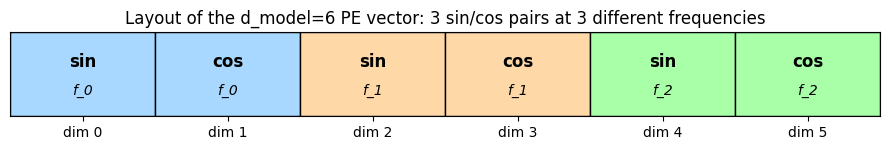

In [33]:
# Visualize which columns are sin, which are cos, and which frequency they belong to.
fig, ax = plt.subplots(figsize=(9, 1.6))
for d in range(d_model):
    pair = d // 2
    is_sin = (d % 2 == 0)
    color = ['#a8d8ff', '#ffd8a8', '#a8ffa8'][pair]
    ax.add_patch(plt.Rectangle((d, 0), 1, 1, facecolor=color, edgecolor='black'))
    ax.text(d + 0.5, 0.65, "sin" if is_sin else "cos",
            ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(d + 0.5, 0.30, f"f_{pair}", ha='center', va='center', fontsize=10, style='italic')
ax.set_xlim(0, d_model); ax.set_ylim(0, 1)
ax.set_xticks([d + 0.5 for d in range(d_model)]); ax.set_xticklabels([f"dim {d}" for d in range(d_model)])
ax.set_yticks([])
ax.set_title("Layout of the d_model=6 PE vector: 3 sin/cos pairs at 3 different frequencies")
plt.tight_layout(); plt.show()

#### Step 3 — Why we need PE: the model can't tell "I love deep learning" from "learning deep love I"

Attention computes `softmax(Q K^T / sqrt(d_k)) V`. If you shuffle the rows of the input, the rows of `Q`, `K`, and `V` shuffle in lockstep — and so do the output rows. **Attention sees a set, not a sequence.**

Let's prove it: attend over our sentence, then attend over its **reverse**, and check that the model gets the same outputs (just in reverse order).

In [34]:
# Same toy attention, applied to "I love deep learning" and "learning deep love I"
torch.manual_seed(0)
W_q = torch.randn(d_model, d_model)
W_k = torch.randn(d_model, d_model)
W_v = torch.randn(d_model, d_model)

def toy_attention(x):
    q, k, v = x @ W_q, x @ W_k, x @ W_v
    s = (q @ k.T) / math.sqrt(d_model)
    w = F.softmax(s, dim=-1)
    return w @ v

x_forward = embedding_table_slice                         # "I love deep learning"
x_reverse = embedding_table_slice.flip(0)                 # "learning deep love I"

out_forward = toy_attention(x_forward)
out_reverse = toy_attention(x_reverse)

# If we flip the reversed-input output back, it should match the forward output exactly.
diff = (out_forward - out_reverse.flip(0)).abs().max()
print(f"Max difference between 'attend(forward)' and 'flip(attend(reversed))' = {diff.item():.2e}")
print()
print("These match to floating-point precision -- attention literally cannot distinguish")
print("the two orderings. Without positional info, 'I love deep learning' and")
print("'learning deep love I' produce the same set of token outputs.")

Max difference between 'attend(forward)' and 'flip(attend(reversed))' = 5.96e-08

These match to floating-point precision -- attention literally cannot distinguish
the two orderings. Without positional info, 'I love deep learning' and
'learning deep love I' produce the same set of token outputs.


#### Step 4 — The frequencies (`div_term`)

We need `d_model/2 = 3` frequencies, one per sin/cos pair. The formula is:

$$
f_i = \frac{1}{10000^{2i/d_{\text{model}}}}, \quad i = 0, 1, 2
$$

Two design choices to unpack:

**Why geometrically spaced (instead of equally spaced)?**
We want one frequency for every *scale* the model might care about: very local (adjacent tokens) all the way up to very long-range (whole-sequence position). Geometric spacing means each frequency is roughly `10000^(2/d_model)` times slower than the previous one — covering many orders of magnitude with few values.

**Why the constant 10000?**
It's a hyperparameter from the original paper: chosen large enough that even the slowest dim's wave doesn't repeat within the longest sequence the model will see. With `d_model=512` and 10000, the slowest period is about `2π × 10000 ≈ 62 800` positions — comfortably longer than typical sequences.

In [35]:
# Compute the 3 frequencies for our d_model=6 example.
i_vals = torch.arange(0, d_model, 2)  # tensor([0, 2, 4])
div_term = torch.exp(i_vals.float() * (-math.log(10000.0) / d_model))
print(f"i values:        {i_vals.tolist()}    (these are 2i for i=0,1,2)")
print(f"frequencies f_i: {[round(f, 6) for f in div_term.tolist()]}")
print()
print("Per pair:")
for i, f in enumerate(div_term.tolist()):
    period = 2 * math.pi / f
    print(f"  pair {i} (dims {2*i},{2*i+1}): f_{i} = {f:.6f}   period ~= {period:8.2f} positions")
print()
print(f"Notice: f_0 / f_1 = {div_term[0]/div_term[1]:.2f}    f_1 / f_2 = {div_term[1]/div_term[2]:.2f}")
print(f"Each frequency is about 10000^(2/6) = {10000**(2/6):.2f}x slower than the previous.")

i values:        [0, 2, 4]    (these are 2i for i=0,1,2)
frequencies f_i: [1.0, 0.046416, 0.002154]

Per pair:
  pair 0 (dims 0,1): f_0 = 1.000000   period ~=     6.28 positions
  pair 1 (dims 2,3): f_1 = 0.046416   period ~=   135.37 positions
  pair 2 (dims 4,5): f_2 = 0.002154   period ~=  2916.40 positions

Notice: f_0 / f_1 = 21.54    f_1 / f_2 = 21.54
Each frequency is about 10000^(2/6) = 21.54x slower than the previous.


#### Step 5 — Build the PE matrix (and trace one cell by hand)

Now apply the formula `PE[pos, 2i] = sin(pos * f_i)` and `PE[pos, 2i+1] = cos(pos * f_i)` for every `(pos, dim)` pair. Result is a `(T=4, d_model=6)` matrix.

Let's hand-compute one specific entry — the value for **"deep" at position 2** in dim 0:

```
pos = 2  (third token, "deep")
dim = 0  (first dimension, which is sin at frequency f_0 = 1.0)

PE[2, 0] = sin(pos * f_0)
        = sin(2 * 1.0)
        = sin(2.0)
        ≈ 0.9093
```

And for `PE[2, 1]` (cos at the same frequency):

```
PE[2, 1] = cos(pos * f_0)
        = cos(2 * 1.0)
        = cos(2.0)
        ≈ -0.4161
```

So the PE for "deep" starts with `[0.9093, -0.4161, ...]`. Let's compute the whole matrix and confirm those two numbers.

In [36]:
pe = torch.zeros(T, d_model)
position = torch.arange(T).float().unsqueeze(1)   # shape (T, 1) = [[0],[1],[2],[3]]
angles = position * div_term                      # shape (T, 3) = pos * f_i for each pair

pe[:, 0::2] = torch.sin(angles)   # even cols: sin
pe[:, 1::2] = torch.cos(angles)   # odd  cols: cos

print("PE matrix for our sentence (rows = positions, cols = dims):")
print()
header = " " * 12 + "  ".join(f" dim{d:1d} " for d in range(d_model))
print(header)
for t, word in enumerate(sentence):
    row_str = "  ".join(f"{v:+6.4f}" for v in pe[t].tolist())
    print(f"  pos {t} ({word:<8s})  {row_str}")
print()
print("Verify our hand calculation:")
print(f"  PE[2, 0] = sin(2 * 1.0)   = sin(2.0)  = {pe[2,0].item():+.4f}   (we predicted +0.9093)")
print(f"  PE[2, 1] = cos(2 * 1.0)   = cos(2.0)  = {pe[2,1].item():+.4f}   (we predicted -0.4161)")

PE matrix for our sentence (rows = positions, cols = dims):

             dim0    dim1    dim2    dim3    dim4    dim5 
  pos 0 (I       )  +0.0000  +1.0000  +0.0000  +1.0000  +0.0000  +1.0000
  pos 1 (love    )  +0.8415  +0.5403  +0.0464  +0.9989  +0.0022  +1.0000
  pos 2 (deep    )  +0.9093  -0.4161  +0.0927  +0.9957  +0.0043  +1.0000
  pos 3 (learning)  +0.1411  -0.9900  +0.1388  +0.9903  +0.0065  +1.0000

Verify our hand calculation:
  PE[2, 0] = sin(2 * 1.0)   = sin(2.0)  = +0.9093   (we predicted +0.9093)
  PE[2, 1] = cos(2 * 1.0)   = cos(2.0)  = -0.4161   (we predicted -0.4161)


##### Heatmap of the PE matrix

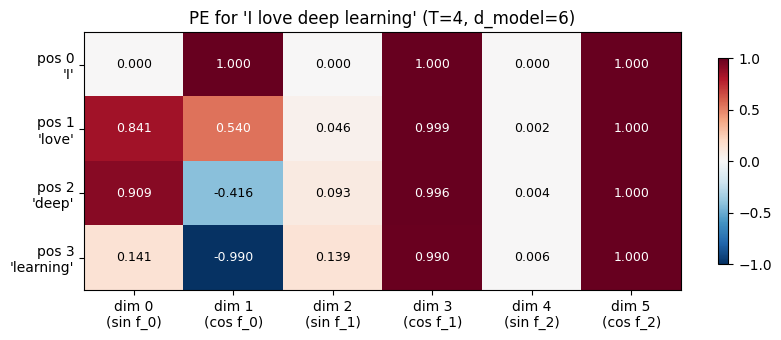

In [37]:
fig, ax = plt.subplots(figsize=(8.5, 3.5))
im = ax.imshow(pe.numpy(), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(d_model))
ax.set_yticks(range(T))
ax.set_xticklabels([f"dim {d}\n({'sin' if d%2==0 else 'cos'} f_{d//2})" for d in range(d_model)])
ax.set_yticklabels([f"pos {t}\n'{w}'" for t, w in enumerate(sentence)])
ax.set_title("PE for 'I love deep learning' (T=4, d_model=6)")
for i in range(T):
    for j in range(d_model):
        ax.text(j, i, f"{pe[i, j]:.3f}", ha='center', va='center', fontsize=9,
                color='white' if abs(pe[i, j]) > 0.5 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

#### Step 6 — Add PE to the token embeddings

The final input to the Transformer block is `embedding + PE`. Each token's vector now carries information about *which token it is* AND *where it sits*.

Notice especially: if "I" had appeared at position 3 instead of position 0, its final vector would be different — the model can tell *the same word at different positions* apart.

In [38]:
final_input = embedding_table_slice + pe

print("token embedding (what 'I love deep learning' looks like to the model):")
print(embedding_table_slice)
print("\nPE (positional 'stamp' added):")
print(pe)
print("\nfinal input = embedding + PE  (this is what attention will see):")
print(final_input)

token embedding (what 'I love deep learning' looks like to the model):
tensor([[ 0.2100, -0.4500,  0.1300,  0.3000, -0.0800,  0.0500],
        [-0.1000,  0.3200, -0.2700,  0.1100,  0.4000, -0.1800],
        [ 0.0400,  0.1800,  0.4200, -0.2200,  0.1500,  0.2700],
        [-0.3300,  0.0700,  0.2100,  0.3600, -0.1400,  0.0900]])

PE (positional 'stamp' added):
tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0464,  0.9989,  0.0022,  1.0000],
        [ 0.9093, -0.4161,  0.0927,  0.9957,  0.0043,  1.0000],
        [ 0.1411, -0.9900,  0.1388,  0.9903,  0.0065,  1.0000]])

final input = embedding + PE  (this is what attention will see):
tensor([[ 0.2100,  0.5500,  0.1300,  1.3000, -0.0800,  1.0500],
        [ 0.7415,  0.8603, -0.2236,  1.1089,  0.4022,  0.8200],
        [ 0.9493, -0.2361,  0.5127,  0.7757,  0.1543,  1.2700],
        [-0.1889, -0.9200,  0.3488,  1.3503, -0.1335,  1.0900]])


##### Side-by-side: embedding, PE, and their sum

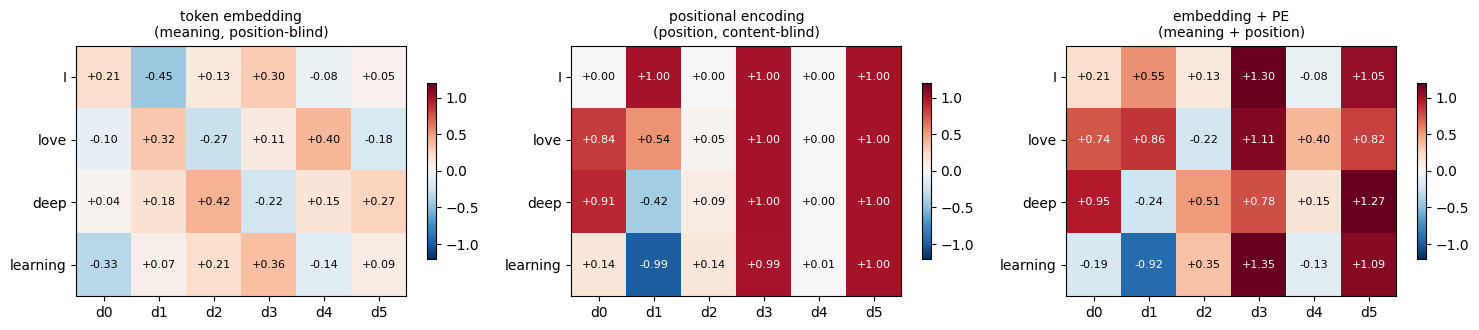

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, mat, title in zip(axes,
                           [embedding_table_slice.numpy(), pe.numpy(), final_input.numpy()],
                           ["token embedding\n(meaning, position-blind)",
                            "positional encoding\n(position, content-blind)",
                            "embedding + PE\n(meaning + position)"]):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1.2, vmax=1.2, aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(d_model)); ax.set_xticklabels([f"d{d}" for d in range(d_model)])
    ax.set_yticks(range(T)); ax.set_yticklabels(sentence)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:+.2f}", ha='center', va='center', fontsize=8,
                    color='white' if abs(mat[i, j]) > 0.6 else 'black')
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

#### Step 7 — Why sin AND cos? (three reasons, surface to deep)

There are three reasons the formula is built from `sin` and `cos` rather than, say, polynomials or one of them alone — and they get progressively deeper.

##### Reason 1 — Bounded values (the surface reason)

Both `sin` and `cos` always return values in `[-1, +1]`, no matter how large `pos` gets. If we used `pos` directly, position 1000 would dominate position 1 by a factor of 1000 and overwhelm the actual token embedding. Using sin/cos keeps every position contributing equally-sized values to the sum.

##### Reason 2 — Multiple frequencies = unique fingerprint per position (the practical reason)

A *single* sine wave repeats — `sin(0) = sin(2π)`, so positions 0 and ~6.28 would collide. By stacking **multiple frequencies** (each pair of dims at a different `f_i`), we get a unique vector for every position. It's like reading a clock with hour, minute, and second hands all at once: each hand alone has collisions, but the combined reading uniquely identifies the time.

For our `d_model=6` example with three frequency pairs:

| | pair 0 (fast) | pair 1 (medium) | pair 2 (slow) |
|---|---|---|---|
| **f_i** | 1.0 | 0.0464 | 0.00215 |
| **period** | ~6.3 positions | ~135 positions | ~2920 positions |
| **role** | distinguishes nearby positions | distinguishes mid-range positions | distinguishes far-apart positions |

A position is uniquely identified by where it sits on *all three* clocks simultaneously.

##### Reason 3 — Shift = rotation (the deep reason — *why pairs of the same frequency*)

This is the one that explains why we use sin AND cos at the **same frequency** instead of two unrelated functions.

Take any pair `(sin(pos·f), cos(pos·f))`. That's a point on the unit circle, with angle `pos·f`. Move from position `pos` to `pos+k` and the point **rotates by exactly `k·f` radians** — the same rotation, regardless of where we started.

```
position 0:  (sin 0, cos 0) = (0.000,  1.000)    angle 0
position 1:  (sin 1, cos 1) = (0.841,  0.540)    angle 1 rad (~57 deg)
position 2:  (sin 2, cos 2) = (0.909, -0.416)    angle 2 rad (~115 deg)
```

In matrix form, there's a 2×2 rotation matrix `R(k·f_i)` such that

$$
\begin{pmatrix} \mathrm{PE}[pos+k, 2i] \ \mathrm{PE}[pos+k, 2i+1] \end{pmatrix}
= R(k \cdot f_i) \begin{pmatrix} \mathrm{PE}[pos, 2i] \ \mathrm{PE}[pos, 2i+1] \end{pmatrix}
$$

> **Position-shift is now a *linear* operation on the PE vector — just a rotation per pair.**

That's huge for the model. Attention computes `Q W_q`, `K W_k` — *linear* projections of the input. So the model can implement "attend to the token 3 positions back" by **learning the right rotation matrix**. The relative-position pattern is detectable using the same kind of layer the model already has.

The next two cells visualize this rotation, and then we'll prove it numerically.


##### Visualization: each pair traces out a rotating point on a circle

For each of the 3 pairs (different frequencies), plot the position 0, 1, 2, 3 as `(sin, cos)` points. Faster frequency = bigger angle per step.

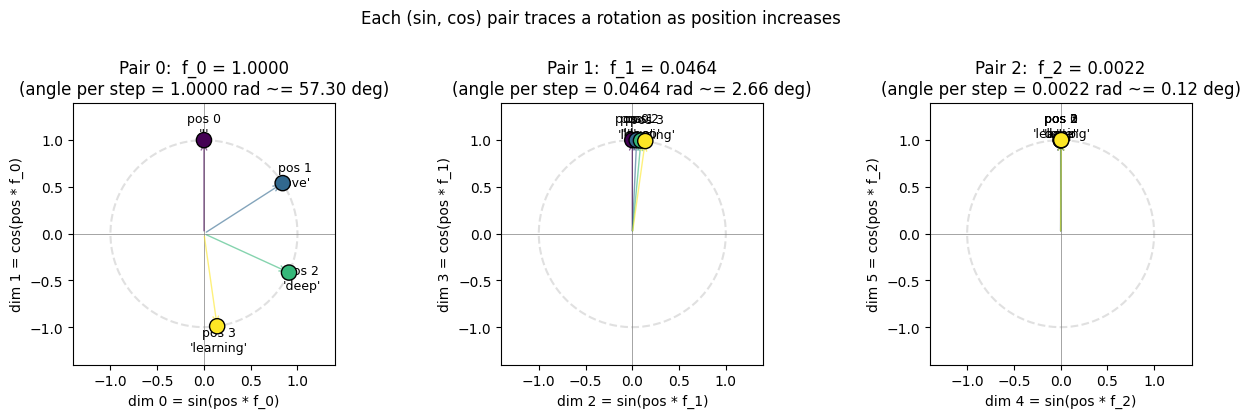

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for pair_i, ax in enumerate(axes):
    f = div_term[pair_i].item()
    sins = pe[:, 2*pair_i].numpy()
    coss = pe[:, 2*pair_i + 1].numpy()
    # Unit circle
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.sin(theta), np.cos(theta), '--', color='lightgrey', alpha=0.7)
    # Position points
    ax.scatter(sins, coss, s=120, c=range(T), cmap='viridis', zorder=5, edgecolor='black')
    # Arrows from origin
    for t in range(T):
        ax.annotate('', xy=(sins[t], coss[t]), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=plt.cm.viridis(t/(T-1)), alpha=0.6))
        ax.text(sins[t]*1.15, coss[t]*1.15, f"pos {t}\n'{sentence[t]}'",
                ha='center', va='center', fontsize=9)
    ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.set_xlabel(f"dim {2*pair_i} = sin(pos * f_{pair_i})")
    ax.set_ylabel(f"dim {2*pair_i+1} = cos(pos * f_{pair_i})")
    ax.set_title(f"Pair {pair_i}:  f_{pair_i} = {f:.4f}\n(angle per step = {f:.4f} rad ~= {math.degrees(f):.2f} deg)")
plt.suptitle("Each (sin, cos) pair traces a rotation as position increases", y=1.02)
plt.tight_layout(); plt.show()

##### Numerical verification: shift = rotation

Let's prove the rotation property numerically. Take pair 0 (frequency `f_0 = 1.0`). The claim is:

> `PE_pair_0(pos+1) = R(f_0) @ PE_pair_0(pos)` for any `pos`,
>
> where `R(theta) = [[cos(theta), sin(theta)], [-sin(theta), cos(theta)]]`.

We'll build `R(f_0)`, apply it to position 0's pair, and check we get position 1's pair.

In [41]:
# Pick any pair — let's use pair 0 (dims 0 and 1) at frequency f_0.
f = div_term[0].item()
print(f"Pair 0 frequency: f_0 = {f}")
print()

# Rotation matrix that should map PE_pair(pos) to PE_pair(pos + 1)
R = torch.tensor([[ math.cos(f), math.sin(f)],
                  [-math.sin(f), math.cos(f)]])
print("Rotation matrix R(f_0):")
print(R)
print()

# PE at each position for pair 0 (dims 0, 1)
for pos in range(T - 1):
    v_pos       = pe[pos,   0:2]   # (sin(pos*f), cos(pos*f))
    v_pos_plus1 = pe[pos+1, 0:2]   # (sin((pos+1)*f), cos((pos+1)*f))
    predicted   = R @ v_pos        # apply rotation
    err = (predicted - v_pos_plus1).abs().max().item()
    print(f"  pos {pos} -> pos {pos+1}:")
    print(f"    PE_pair(pos)        = {v_pos.tolist()}")
    print(f"    R(f_0) @ PE_pair(pos)  = {predicted.tolist()}")
    print(f"    PE_pair(pos+1)      = {v_pos_plus1.tolist()}")
    print(f"    max error           = {err:.2e}    {'OK' if err < 1e-6 else 'MISMATCH'}")
    print()

Pair 0 frequency: f_0 = 1.0

Rotation matrix R(f_0):
tensor([[ 0.5403,  0.8415],
        [-0.8415,  0.5403]])

  pos 0 -> pos 1:
    PE_pair(pos)        = [0.0, 1.0]
    R(f_0) @ PE_pair(pos)  = [0.8414709568023682, 0.5403022766113281]
    PE_pair(pos+1)      = [0.8414709568023682, 0.5403023362159729]
    max error           = 5.96e-08    OK

  pos 1 -> pos 2:
    PE_pair(pos)        = [0.8414709568023682, 0.5403023362159729]
    R(f_0) @ PE_pair(pos)  = [0.9092974066734314, -0.41614678502082825]
    PE_pair(pos+1)      = [0.9092974066734314, -0.416146844625473]
    max error           = 5.96e-08    OK

  pos 2 -> pos 3:
    PE_pair(pos)        = [0.9092974066734314, -0.416146844625473]
    R(f_0) @ PE_pair(pos)  = [0.14111998677253723, -0.9899924993515015]
    PE_pair(pos+1)      = [0.14112000167369843, -0.9899924993515015]
    max error           = 1.49e-08    OK



**That's the magic.** Shifting the position by 1 is exactly a rotation by `f_0` radians in the `(sin, cos)` plane of pair 0 — for *any* starting position. Same rotation, only the starting point differs.

##### Why pairs at the *same* frequency? (and why sin alone doesn't work)

The trig identity makes it explicit:

$$
\sin(pos + k) = \sin(pos)\cos(k) + \cos(pos)\sin(k)
$$

The right-hand side needs **both `sin(pos)` and `cos(pos)`** to express the shifted value. With sin alone, you cannot write `sin(pos+k)` as a linear combination of features at position `pos` — the relationship becomes nonlinear, and the model would have to learn a much harder mapping.

Two separate features at unrelated frequencies (e.g. `sin(pos)` and `sin(pos·1.7)`) wouldn't help either — they don't combine cleanly. It has to be **same frequency, paired sin and cos**, so they form a 2D rotating point.

##### Recap of the three reasons

1. **Bounded** — sin/cos stay in `[-1, +1]` so they don't overwhelm the embedding.
2. **Multiple frequencies** — a "fingerprint" of values across many wavelengths uniquely identifies every position.
3. **Same-frequency sin/cos pairs** — make position-shift a 2D rotation, i.e. a *linear* operation that the model's linear projections can detect.

That's why the formula looks the way it does — every part is doing a job.

#### Step 8 — Property check: every position is unique

If two positions had the same PE vector, the model couldn't tell them apart. With multiple frequencies, this is essentially guaranteed for any reasonable sequence length.

In [42]:
dists = torch.cdist(pe, pe)
print("Pairwise Euclidean distances between PE rows:")
print(f"           {' '.join(f'pos {p}' for p in range(T))}")
for i in range(T):
    row = "  ".join(f"{dists[i, j].item():.3f}" for j in range(T))
    print(f"  pos {i}    {row}")
print()
print("Diagonal = 0 (a row equals itself). Every off-diagonal > 0 -> all positions distinct.")

Pairwise Euclidean distances between PE rows:
           pos 0 pos 1 pos 2 pos 3
  pos 0    0.000  0.960  1.686  2.000
  pos 1    0.960  0.000  0.960  1.686
  pos 2    1.686  0.960  0.000  0.960
  pos 3    2.000  1.686  0.960  0.000

Diagonal = 0 (a row equals itself). Every off-diagonal > 0 -> all positions distinct.


#### Step 9 — Property check: dot products depend only on the offset

Because PE is built from rotations, the dot product `PE(pos_a) · PE(pos_b)` depends only on `b - a`, not on the absolute positions. Diagonals of the dot-product matrix are constant.

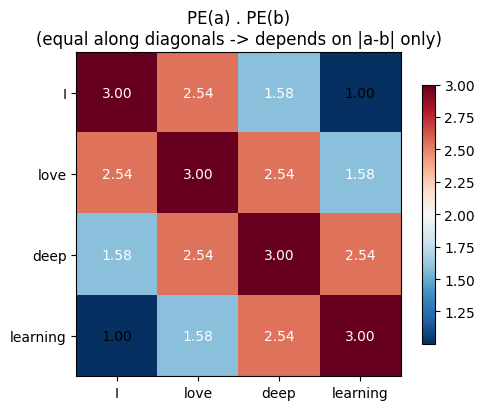

Look down each diagonal: the values are (nearly) the same.
  Main diagonal (offset 0): all equal -> self-similarity
  First off-diagonal (offset 1): all equal -> 'one step apart' similarity
  ...and so on. The model can use this to detect relative positions.


In [43]:
dots = pe @ pe.T  # (T, T)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(dots.numpy(), cmap='RdBu_r')
ax.set_xticks(range(T)); ax.set_yticks(range(T))
ax.set_xticklabels(sentence); ax.set_yticklabels(sentence)
ax.set_title("PE(a) . PE(b)\n(equal along diagonals -> depends on |a-b| only)")
for i in range(T):
    for j in range(T):
        ax.text(j, i, f"{dots[i,j]:.2f}", ha='center', va='center',
                color='white' if abs(dots[i,j]) > 1.5 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

print("Look down each diagonal: the values are (nearly) the same.")
print("  Main diagonal (offset 0): all equal -> self-similarity")
print("  First off-diagonal (offset 1): all equal -> 'one step apart' similarity")
print("  ...and so on. The model can use this to detect relative positions.")

#### Recap

We took the sentence **"I love deep learning"** and walked it through every step of positional encoding:

1. Tokenized -> integer IDs -> 6-dim embeddings (a `(4, 6)` matrix).
2. Showed dimensions: `T=4` tokens, `d_model=6` features per token, with 3 sin/cos pairs.
3. Demonstrated permutation invariance: without PE, the model can't tell "I love deep learning" from its reverse.
4. Computed the 3 frequencies, geometrically spaced via `10000^(-2i/d_model)`.
5. Filled in the PE matrix and verified one cell by hand: `PE[2, 0] = sin(2) ~= 0.909`.
6. Added PE to embeddings — the *same word at a different position* now has a different vector.
7. Explained the **rotation property**: sin AND cos at the same frequency form a 2D unit vector that *rotates* by `f_i` per position step. Shifting position is a linear (rotation) operation — exactly what the linear Q/K projections can detect.
8. Verified uniqueness: no two positions have the same PE.
9. Verified the relative-offset property: `PE(a) . PE(b)` depends only on `b - a`.

With this picture in hand, the larger heatmap below (for `T=64, d_model=64`) is just the same construction, scaled up.

### Visualization 1: the sinusoidal PE as a heatmap

Each row = one position. Each column = one embedding dimension. The classic striped pattern emerges: low dims (left) change fast between rows, high dims (right) change slowly.

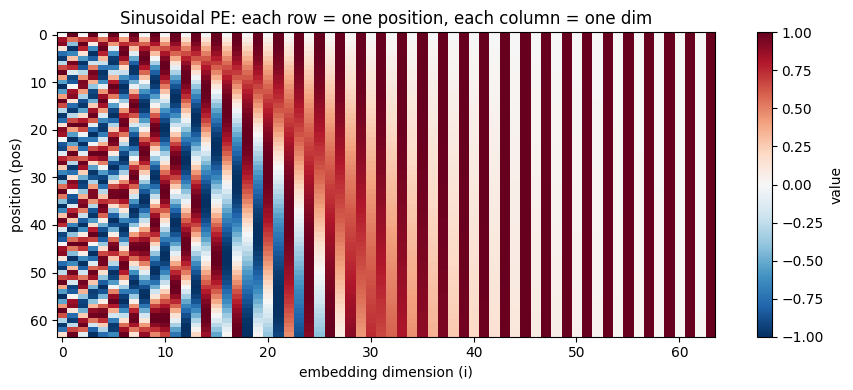

In [44]:
from pos_encoding import SinusoidalPositionalEncoding

max_len, d_model = 64, 64
spe = SinusoidalPositionalEncoding(max_len=max_len, d_model=d_model)
pe_matrix = spe.pe.numpy()  # (64, 64)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pe_matrix, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel("embedding dimension (i)")
ax.set_ylabel("position (pos)")
ax.set_title("Sinusoidal PE: each row = one position, each column = one dim")
fig.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()

### Visualization 2: a few dimensions as waves

Plotting dimensions 0, 4, 16, 32 shows how the frequency decreases as dimension index grows. Dim 0 is a fast wave, dim 32 barely changes across 64 positions.

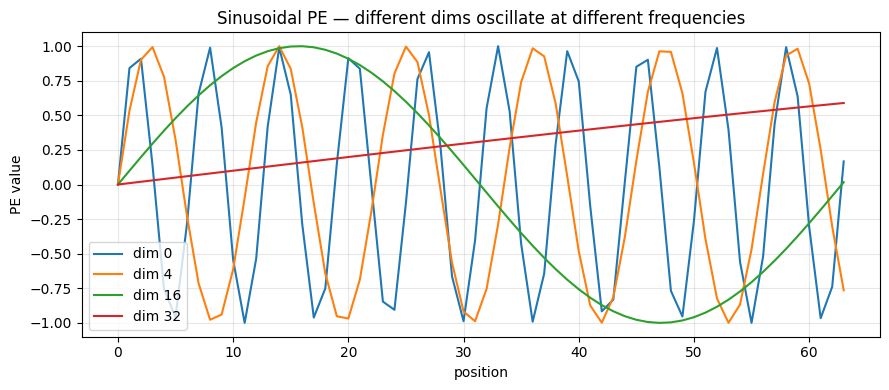

In [45]:
fig, ax = plt.subplots(figsize=(9, 4))
for d in [0, 4, 16, 32]:
    ax.plot(pe_matrix[:, d], label=f"dim {d}")
ax.set_xlabel("position")
ax.set_ylabel("PE value")
ax.set_title("Sinusoidal PE — different dims oscillate at different frequencies")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Code — adding PE to a fake batch of embeddings

`pos_encoding.py` wraps the formula in an `nn.Module`. Its `forward(x)` adds the positional matrix to the input embeddings and returns the sum.

In [46]:
# Pretend we already have token embeddings (B=2, T=10, d_model=64)
x = torch.randn(2, 10, 64)
x_with_pos = spe(x)
print("input shape: ", x.shape)
print("output shape:", x_with_pos.shape)
print("first 5 values of token 0 position 0 before PE:", x[0, 0, :5].numpy())
print("first 5 values of token 0 position 0 after  PE:", x_with_pos[0, 0, :5].numpy())

input shape:  torch.Size([2, 10, 64])
output shape: torch.Size([2, 10, 64])
first 5 values of token 0 position 0 before PE: [-1.612 -0.479 -0.143 -0.317  0.967]
first 5 values of token 0 position 0 after  PE: [-1.612  0.521 -0.143  0.683  0.967]


### Shape trace

| Stage | Shape | Meaning |
|-------|-------|---------|
| Input `x` | `(B, T, d_model)` | token embeddings |
| PE matrix | `(T, d_model)` | looked up from a `(max_len, d_model)` table |
| Output | `(B, T, d_model)` | `x + pe` — broadcast over batch |

**Key takeaway:** PE is added, not concatenated. The model learns to use part of the embedding capacity for position.

---
## 1.2 Self-attention from first principles (NumPy)

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]

    pe["1.1 Positional Encoding<br>add position info"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward<br>Linear -> GELU -> Linear"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style pe fill:#e8e8e8,stroke:#bbb,color:#777
    style ln1 fill:#e8e8e8,stroke:#bbb,color:#777
    style mha fill:#fdebd0,stroke:#b35900,stroke-width:3px,color:#000
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style ln2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

### The question

Each token needs to gather information from other tokens. Which tokens? How much from each? **Attention** answers this by comparing every pair of tokens through *queries* and *keys*, then mixing their *values* weighted by similarity.

### The database analogy

Imagine a query-able database:

| Concept | Database | Attention |
|---|---|---|
| **Query** (Q) | "what am I looking for?" | token's question — a vector |
| **Key** (K) | the record's label/index | token's advertised content — a vector |
| **Value** (V) | what you retrieve if the key matches | what the token actually shares — a vector |

In classical databases, you check `query == key` (exact match). In attention, we check `similarity(query, key)` (soft match via dot product), then take a weighted average of values.

### The formula

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

Step by step:
1. **`Q, K, V = X W_q, X W_k, X W_v`** — project input into three learned spaces
2. **`S = Q K^\top`** — scores: how much each query matches each key (dot product = similarity)
3. **`S = S / sqrt(d_k)`** — scale down so softmax doesn't saturate (values don't blow up as `d_k` grows)
4. **`S[i, j] = -infinity for j > i`** — causal mask: token `i` can't look at future tokens `j > i`
5. **`W = softmax(S)`** — normalize each row to a probability distribution over past tokens
6. **`Out = W V`** — weighted sum of values

### Tiny concrete example (T=3, d_model=4, d_k=2)

We'll use `attn_numpy_demo.py`'s hand-picked numbers so the matrix shapes are walkable on paper.

In [47]:
# Toy input: 1 batch, 3 tokens, 4-dim embeddings
X = np.array([[[0.1, 0.2, 0.3, 0.4],
               [0.5, 0.4, 0.3, 0.2],
               [0.0, 0.1, 0.0, 0.1]]], dtype=np.float32)

# Fixed Q, K, V projection matrices (would be learned in a real model)
Wq = np.array([[ 0.2, -0.1], [ 0.0,  0.1], [ 0.1,  0.2], [-0.1,  0.0]], dtype=np.float32)
Wk = np.array([[ 0.1,  0.1], [ 0.0, -0.1], [ 0.2,  0.0], [ 0.0,  0.2]], dtype=np.float32)
Wv = np.array([[ 0.1,  0.0], [-0.1,  0.1], [ 0.2, -0.1], [ 0.0,  0.2]], dtype=np.float32)

Q = X @ Wq  # (1, 3, 2)
K = X @ Wk
V = X @ Wv
print("Q (3 tokens x 2 dims):\n", Q[0])
print("\nK:\n", K[0])
print("\nV:\n", V[0])

Q (3 tokens x 2 dims):
 [[ 0.01  0.07]
 [ 0.11  0.05]
 [-0.01  0.01]]

K:
 [[0.07 0.07]
 [0.11 0.05]
 [0.   0.01]]

V:
 [[ 0.05  0.07]
 [ 0.07  0.05]
 [-0.01  0.03]]


### Visualization: the full attention pipeline as four matrices

Left to right: **Q, K, V** as heatmaps, then the **scores `Q @ Kᵀ`**, then the **weights after softmax + causal mask**, then the **output `W @ V`**. Each row of the weights matrix sums to 1 (it's a probability distribution over past tokens).

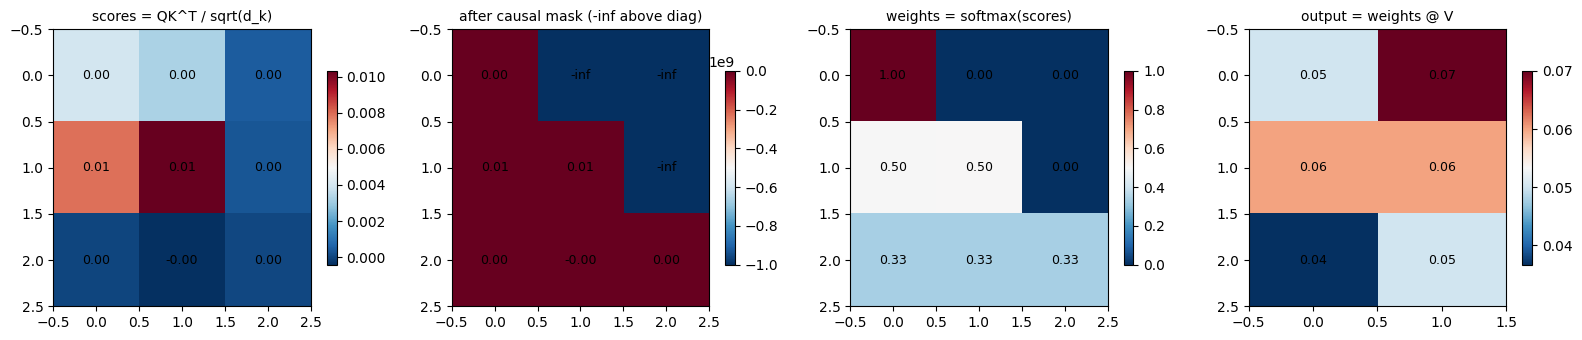

In [48]:
scale = 1.0 / np.sqrt(Q.shape[-1])
scores = (Q @ K.transpose(0, 2, 1)) * scale  # (1, 3, 3)

# Causal mask: upper triangle set to -inf
mask = np.triu(np.ones((3, 3), dtype=bool), k=1)
scores_masked = np.where(mask, -1e9, scores[0])

# Softmax row-wise
weights = np.exp(scores_masked - scores_masked.max(axis=-1, keepdims=True))
weights = weights / weights.sum(axis=-1, keepdims=True)
out = weights @ V[0]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, mat, title in zip(
    axes,
    [scores[0], scores_masked, weights, out],
    ["scores = QK^T / sqrt(d_k)", "after causal mask (-inf above diag)", "weights = softmax(scores)", "output = weights @ V"],
):
    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r')
    ax.set_title(title, fontsize=10)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if val < -1e6:
                text = "-inf"
            else:
                text = f"{val:.2f}"
            ax.text(j, i, text, ha='center', va='center', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

### Reading the weights matrix

Each row of `weights` is "how much does token `i` attend to each earlier token `j`?"
- **Row 0** (first token): `[1, 0, 0]` — can only look at itself
- **Row 1** (second token): `[w1, w2, 0]` — mixes tokens 0 and 1
- **Row 2** (third token): `[w1, w2, w3]` — mixes all three

This triangular structure is the signature of **causal** attention. The model can't peek at the future — essential for next-token prediction.

### Shape trace

| Stage | Shape | Formula |
|-------|-------|---------|
| Input `X` | `(B, T, d_model)` | tokens after embedding + PE |
| `Q, K, V` | each `(B, T, d_k)` | `X @ W_q`, etc. |
| `Q @ K^T` | `(B, T, T)` | similarity between all token pairs |
| `softmax` result | `(B, T, T)` | each row sums to 1 |
| Output | `(B, T, d_k)` | `weights @ V` |

---
## 1.3 Single-Head Attention — traced one step at a time

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    pe["1.1 Positional Encoding"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]
    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output
    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style pe fill:#e8e8e8,stroke:#bbb,color:#777
    style ln1 fill:#e8e8e8,stroke:#bbb,color:#777
    style mha fill:#fdebd0,stroke:#b35900,stroke-width:3px,color:#000
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style ln2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

### What we're going to do

We'll take our familiar sentence — **"I love deep learning"** — and walk it through self-attention one operation at a time. At every step you'll see:

- the actual matrix with numbers printed on every cell
- a one-sentence English explanation of *what just happened*
- a one-sentence answer to *why it matters*

We'll use small dimensions so every value fits on screen:
- `T = 4` tokens (`I`, `love`, `deep`, `learning`)
- `d_model = 6` (each token's incoming vector has 6 features)
- `d_k = 4` (the size of the attention "subspace" — usually smaller than `d_model`)

The big question attention answers is:

> **For each token, how should I mix in information from the earlier tokens?**

That's it. The math below is just one specific way to compute that mixing.

### Step 0 — Our starting point

This is the input to attention: the same `(T, d_model) = (4, 6)` tensor we built in Section 1.1 (token embeddings + positional encoding). Each row is one token's vector — what the model "knows" about that word so far.

In [49]:
# Reuse the input we built in Section 1.1
torch.manual_seed(42)
T, d_model = 4, 6
sentence = ["I", "love", "deep", "learning"]

# Same embedding + PE result from Section 1.1
embedding_table_slice = torch.tensor([
    [ 0.21, -0.45,  0.13,  0.30, -0.08,  0.05],
    [-0.10,  0.32, -0.27,  0.11,  0.40, -0.18],
    [ 0.04,  0.18,  0.42, -0.22,  0.15,  0.27],
    [-0.33,  0.07,  0.21,  0.36, -0.14,  0.09],
])

# Recompute PE for T=4, d_model=6
pe = torch.zeros(T, d_model)
position = torch.arange(T).float().unsqueeze(1)
div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

x = embedding_table_slice + pe   # this is what attention sees: (T=4, d_model=6)
print("Input x  (rows = tokens, cols = features):")
print(x)
print(f"\nshape: {tuple(x.shape)}  = (T=4 tokens, d_model=6 features)")

Input x  (rows = tokens, cols = features):
tensor([[ 0.2100,  0.5500,  0.1300,  1.3000, -0.0800,  1.0500],
        [ 0.7415,  0.8603, -0.2236,  1.1089,  0.4022,  0.8200],
        [ 0.9493, -0.2361,  0.5127,  0.7757,  0.1543,  1.2700],
        [-0.1889, -0.9200,  0.3488,  1.3503, -0.1335,  1.0900]])

shape: (4, 6)  = (T=4 tokens, d_model=6 features)


### Step 1 — Three "lenses": W_q, W_k, W_v

Attention has three learnable matrices, all of shape `(d_model, d_k) = (6, 4)`. They're three different lenses through which we look at the same input:

| Matrix | What it produces | What that means |
|--------|------------------|-----------------|
| **W_q** | Query vectors `q_i` | "what is token `i` looking for?" |
| **W_k** | Key vectors `k_i`   | "what does token `i` advertise about itself?" |
| **W_v** | Value vectors `v_i` | "what would token `i` share if attended to?" |

Database analogy: **Q is the search request**, **K is the index/label of each item**, **V is the actual content** the model retrieves. We use dot product `q·k` as a soft "is this a match?" score.

In a real model these matrices are learned by training. Here we just initialize them randomly and watch the math flow — the *structure* is the same as a trained model.

In [50]:
d_k = 4   # size of the attention subspace; in real models often = d_model // n_head

W_q = torch.randn(d_model, d_k) * 0.5
W_k = torch.randn(d_model, d_k) * 0.5
W_v = torch.randn(d_model, d_k) * 0.5

print(f"W_q shape: {tuple(W_q.shape)}    'how to ask a question'")
print(f"W_k shape: {tuple(W_k.shape)}    'how to advertise content'")
print(f"W_v shape: {tuple(W_v.shape)}    'how to package what to share'")
print()
print("All three are (d_model=6, d_k=4) — they project a 6-dim token vector into a 4-dim subspace.")

W_q shape: (6, 4)    'how to ask a question'
W_k shape: (6, 4)    'how to advertise content'
W_v shape: (6, 4)    'how to package what to share'

All three are (d_model=6, d_k=4) — they project a 6-dim token vector into a 4-dim subspace.


### Step 2 — Project each token through the three lenses

Multiplying `x @ W_q` gives `Q` of shape `(T, d_k) = (4, 4)`. Each row is one token's query vector. Same for `K` and `V`.

This is just matrix multiplication, but it's worth pausing on the *meaning*: each token now has three different 4-dim representations of itself — one as a "question," one as an "advertisement," and one as "shareable content." The same six input numbers per token, transformed three different ways.

In [51]:
Q = x @ W_q   # (4, 4) — queries
K = x @ W_k   # (4, 4) — keys
V = x @ W_v   # (4, 4) — values

# Pretty-print as labeled tables
def show_tokens_matrix(M, name, col_prefix='dim'):
    print(f"{name}  (rows = tokens, cols = {col_prefix})")
    print("       " + " ".join(f"{col_prefix}{j}".rjust(7) for j in range(M.shape[1])))
    for t, w in enumerate(sentence):
        row = " ".join(f"{v:+.3f}".rjust(7) for v in M[t].tolist())
        print(f"  {w:<9s}{row}")
    print()

show_tokens_matrix(Q, "Q (queries  — 'what each token is asking')")
show_tokens_matrix(K, "K (keys     — 'what each token advertises')")
show_tokens_matrix(V, "V (values   — 'what each token will share')")

Q (queries  — 'what each token is asking')  (rows = tokens, cols = dim)
          dim0    dim1    dim2    dim3
  I         -0.608  -0.186  -1.922  -0.589
  love      +0.045  +0.042  -1.092  -1.607
  deep      +0.095  +0.641  -1.057  -0.670
  learning  -1.484  +0.362  -2.221  +1.055

K (keys     — 'what each token advertises')  (rows = tokens, cols = dim)
          dim0    dim1    dim2    dim3
  I         +0.993  -0.208  -1.836  +0.267
  love      +0.809  +0.052  -1.611  -0.038
  deep      +0.718  -0.153  -0.362  -0.173
  learning  +0.204  -0.715  -1.179  +0.760

V (values   — 'what each token will share')  (rows = tokens, cols = dim)
          dim0    dim1    dim2    dim3
  I         -0.151  +0.646  +1.711  +0.843
  love      -0.133  +0.483  +1.204  +0.721
  deep      -0.539  +0.310  +1.521  +0.643
  learning  -0.606  +0.407  +1.209  +0.902



#### Visualizing Q, K, V

Three heatmaps side by side. Each row = one token. Each column = one of the 4 dimensions of the attention subspace. Notice all three matrices have the same shape `(4, 4)` but different values — they're three different "translations" of the same 4 input tokens.

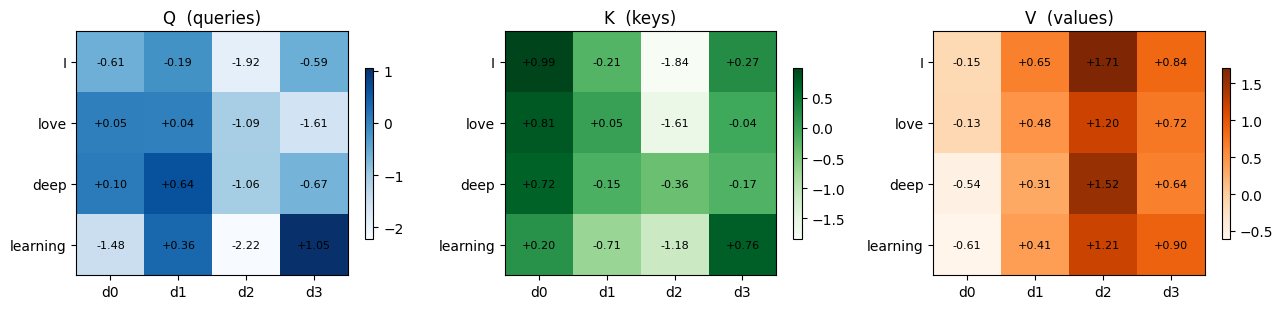

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, M, name, color in zip(
    axes, [Q, K, V],
    ["Q  (queries)", "K  (keys)", "V  (values)"],
    ['Blues', 'Greens', 'Oranges']
):
    M_np = M.numpy()
    im = ax.imshow(M_np, cmap=color, aspect='auto')
    ax.set_xticks(range(d_k)); ax.set_xticklabels([f"d{j}" for j in range(d_k)])
    ax.set_yticks(range(T)); ax.set_yticklabels(sentence)
    ax.set_title(name)
    for i in range(T):
        for j in range(d_k):
            ax.text(j, i, f"{M_np[i,j]:+.2f}", ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

### Step 3 — Compute "compatibility scores" with Q @ K^T

For each token `i`, we want to know: "how well does my query `q_i` match each token's key `k_j`?" Dot product is the natural similarity measure.

`scores = Q @ K^T` does this for all `(i, j)` pairs at once. Result is a `(T, T) = (4, 4)` matrix where:

```
scores[i, j] = q_i · k_j   = how much token i wants to attend to token j
```

Reading rows: **row `i` is "token `i`'s scores against all tokens (including itself)"**.

In [53]:
scores_raw = Q @ K.transpose(-2, -1)   # (4, 4)
print(f"scores shape: {tuple(scores_raw.shape)}    -> one number per (query token, key token) pair")
print()
print("scores[i, j] = q_i . k_j = 'how much should token i attend to token j?'")
print()
print("           " + " ".join(f"{w[:8]:<8s}" for w in sentence) + "  <- key tokens (j)")
for i, w in enumerate(sentence):
    row = " ".join(f"{v:+8.3f}" for v in scores_raw[i].tolist())
    print(f"  {w:<9s}{row}")
print("  ^ query tokens (i)")

scores shape: (4, 4)    -> one number per (query token, key token) pair

scores[i, j] = q_i . k_j = 'how much should token i attend to token j?'

           I        love     deep     learning  <- key tokens (j)
  I          +2.807   +2.618   +0.389   +1.828
  love       +1.613   +1.860   +0.700   +0.046
  deep       +1.723   +1.838   +0.469   +0.298
  learning   +2.811   +2.355   -0.501   +2.858
  ^ query tokens (i)


### Step 4 — Scale by `sqrt(d_k)`

If we run softmax on raw dot products, two problems arise:

1. **Variance grows with `d_k`.** A dot product of two random `d_k`-dim vectors has variance proportional to `d_k`. Bigger numbers go into softmax → softmax becomes "peaky" (almost one-hot) → most of the gradient vanishes.
2. **Training stalls.** Saturated softmax = dead gradients = no learning.

The fix: divide scores by `sqrt(d_k)` to keep their variance roughly 1, regardless of `d_k`. Tiny change, huge stability difference.

In [54]:
scale = 1.0 / math.sqrt(d_k)
scores_scaled = scores_raw * scale

print(f"d_k = {d_k}, sqrt(d_k) = {math.sqrt(d_k):.3f}, so we multiply by 1/sqrt(d_k) = {scale:.3f}")
print(f"Before scaling: scores variance = {scores_raw.var().item():.3f}")
print(f"After scaling:  scores variance = {scores_scaled.var().item():.3f}")
print()
print("scaled scores:")
print("           " + " ".join(f"{w[:8]:<8s}" for w in sentence))
for i, w in enumerate(sentence):
    row = " ".join(f"{v:+8.3f}" for v in scores_scaled[i].tolist())
    print(f"  {w:<9s}{row}")

d_k = 4, sqrt(d_k) = 2.000, so we multiply by 1/sqrt(d_k) = 0.500
Before scaling: scores variance = 1.211
After scaling:  scores variance = 0.303

scaled scores:
           I        love     deep     learning
  I          +1.404   +1.309   +0.194   +0.914
  love       +0.806   +0.930   +0.350   +0.023
  deep       +0.861   +0.919   +0.234   +0.149
  learning   +1.406   +1.178   -0.251   +1.429


### Step 5 — Causal mask: hide the future

This is a **language model**, so when generating "deep" we must NOT let the model peek at "learning" (which comes after). For every row `i`, we set positions `j > i` to `-infinity`. After softmax, `exp(-inf) = 0`, so those positions get zero attention weight.

Visually: keep the lower-triangular part (including diagonal), blank out the upper-right.

| | I | love | deep | learning |
|---|---|---|---|---|
| **I** (i=0) | look at I | -inf | -inf | -inf |
| **love** (i=1) | look at I | look at love | -inf | -inf |
| **deep** (i=2) | look at I | look at love | look at deep | -inf |
| **learning** (i=3) | look at I | look at love | look at deep | look at learning |

In [55]:
# Build the mask (True = blocked, i.e. j > i)
mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
scores_masked = scores_scaled.masked_fill(mask, float('-inf'))

print("masked scores (-inf positions will become 0 after softmax):")
print("           " + " ".join(f"{w[:8]:<8s}" for w in sentence))
for i, w in enumerate(sentence):
    cells = [("   -inf " if v == float('-inf') else f"{v:+8.3f}") for v in scores_masked[i].tolist()]
    print(f"  {w:<9s}" + " ".join(cells))

masked scores (-inf positions will become 0 after softmax):
           I        love     deep     learning
  I          +1.404    -inf     -inf     -inf 
  love       +0.806   +0.930    -inf     -inf 
  deep       +0.861   +0.919   +0.234    -inf 
  learning   +1.406   +1.178   -0.251   +1.429


### Step 6 — Softmax: turn scores into a probability distribution

For each row, softmax converts arbitrary real numbers into non-negative numbers that sum to 1. After this step, **each row is a probability distribution over which earlier tokens to attend to.**

```
weights[i, j] = how much (as a fraction from 0 to 1) token i pays attention to token j
weights[i, :].sum() = 1.0   (every row is a valid distribution)
```

Notice: row 0 (`"I"`) can only attend to itself, so `weights[0, 0] = 1.0`. That's the only place a single-token sequence can put its attention.

In [56]:
weights = F.softmax(scores_masked, dim=-1)   # (4, 4)

print("attention weights (each row sums to 1.0):")
print("           " + " ".join(f"{w[:8]:<8s}" for w in sentence) + "    sum")
for i, w in enumerate(sentence):
    row = " ".join(f"{v:8.4f}" for v in weights[i].tolist())
    print(f"  {w:<9s}{row}    {weights[i].sum().item():.4f}")

attention weights (each row sums to 1.0):
           I        love     deep     learning    sum
  I          1.0000   0.0000   0.0000   0.0000    1.0000
  love       0.4691   0.5309   0.0000   0.0000    1.0000
  deep       0.3856   0.4085   0.2060   0.0000    1.0000
  learning   0.3321   0.2644   0.0634   0.3400    1.0000


#### Visualizing the score → weights pipeline (one figure per stage)

Watch `scores → scaled → masked → weights` evolve. The final heatmap on the right (`weights`) is what the model uses to decide whose information goes where.

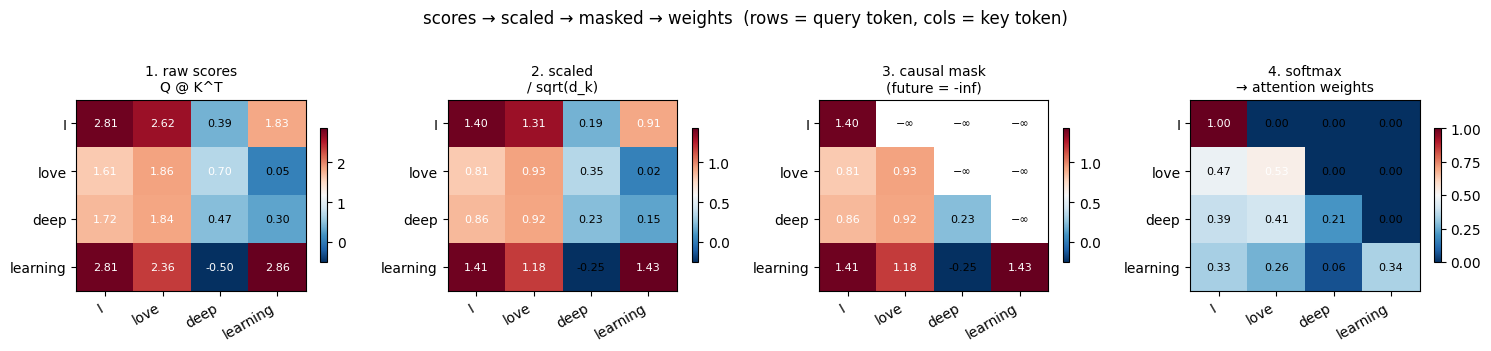

In [57]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
mats = [scores_raw, scores_scaled, scores_masked, weights]
titles = ["1. raw scores\nQ @ K^T",
          "2. scaled\n/ sqrt(d_k)",
          "3. causal mask\n(future = -inf)",
          "4. softmax\n→ attention weights"]

for ax, M, title in zip(axes, mats, titles):
    M_np = M.detach().numpy()
    # Replace -inf with NaN for plotting
    M_plot = np.where(np.isinf(M_np), np.nan, M_np)
    im = ax.imshow(M_plot, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(T)); ax.set_xticklabels(sentence, rotation=30, ha='right')
    ax.set_yticks(range(T)); ax.set_yticklabels(sentence)
    ax.set_title(title, fontsize=10)
    for i in range(T):
        for j in range(T):
            v = M_np[i, j]
            text = "−∞" if v == float('-inf') else f"{v:.2f}"
            ax.text(j, i, text, ha='center', va='center', fontsize=8,
                    color='white' if (not np.isinf(v) and abs(v) > 0.5) else 'black')
    fig.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle("scores → scaled → masked → weights  (rows = query token, cols = key token)", y=1.02)
plt.tight_layout(); plt.show()

### Step 7 — Use the weights to mix V

Final step. Each token's output is a **weighted sum of value vectors** from earlier tokens, using the row of weights we just computed:

```
output[i, :] = weights[i, 0] * V[0] + weights[i, 1] * V[1] + ... + weights[i, i] * V[i]
```

For `"deep"` (row 2), the output mixes V-vectors from `"I"`, `"love"`, and `"deep"` according to its row in `weights`.

In matrix form this is one line: `output = weights @ V`.

In [58]:
out = weights @ V   # (4, 4)

print(f"output shape: {tuple(out.shape)}  = (T={T} tokens, d_k={d_k} features per token)")
print()
print("Each row of `out` is the new representation of that token AFTER attending to past tokens.")
print()
show_tokens_matrix(out, "out (after attention — each row mixes information from earlier tokens)")

# Quick sanity check: manually compute out[2] and compare
manual = sum(weights[2, j] * V[j] for j in range(T))
print(f"Manual check for 'deep' (row 2):")
print(f"  weights[2] = {weights[2].tolist()}")
print(f"  Sum of weights[2,j] * V[j] = {manual.tolist()}")
print(f"  Matches out[2]? {torch.allclose(manual, out[2])}")

output shape: (4, 4)  = (T=4 tokens, d_k=4 features per token)

Each row of `out` is the new representation of that token AFTER attending to past tokens.

out (after attention — each row mixes information from earlier tokens)  (rows = tokens, cols = dim)
          dim0    dim1    dim2    dim3
  I         -0.151  +0.646  +1.711  +0.843
  love      -0.141  +0.559  +1.442  +0.778
  deep      -0.223  +0.510  +1.465  +0.752
  learning  -0.325  +0.500  +1.394  +0.818

Manual check for 'deep' (row 2):
  weights[2] = [0.38556352257728577, 0.4084618091583252, 0.2059747278690338, 0.0]
  Sum of weights[2,j] * V[j] = [-0.22323688864707947, 0.5102205276489258, 1.4649380445480347, 0.7520568370819092]
  Matches out[2]? True


### The whole pipeline in one picture

Putting it all together — this is single-head self-attention end to end:

```
                     x  (T=4, d_model=6)
                          |
            ┌─────────────┼─────────────┐
            ▼             ▼             ▼
        x @ W_q       x @ W_k       x @ W_v       (3 separate projections)
            ▼             ▼             ▼
            Q             K             V          (each (T, d_k))
            └──────┬──────┘             │
                   ▼                    │
              Q @ K^T                   │
                   ▼                    │
               / sqrt(d_k)              │
                   ▼                    │
           apply causal mask            │
                   ▼                    │
                softmax                 │
                   ▼                    │
                weights  ───────────────┤
                                        ▼
                                   weights @ V
                                        │
                                        ▼
                                     output (T, d_k)
```

**One sentence summary:** *for each token, attention computes a weighted average of earlier tokens' value vectors, where the weights are softmaxed dot products between this token's query and every earlier token's key.*

That sentence IS the whole algorithm. Everything else is plumbing to make it work in batches and on GPUs.

### Compare with `single_head.py`

Now look at `single_head.py` — it does *exactly* the steps we just did, wrapped in an `nn.Module` so the W_q, W_k, W_v matrices can be trained by backprop. Reading the file should feel like recognition, not surprise.

In [59]:
from single_head import SingleHeadSelfAttention

torch.manual_seed(0)
head = SingleHeadSelfAttention(d_model=d_model, d_k=d_k)
out_module, weights_module = head(x.unsqueeze(0))   # add batch dim

print(f"Module output shape:  {tuple(out_module.shape)}    = (B, T, d_k)")
print(f"Module weights shape: {tuple(weights_module.shape)} = (B, T, T)")
print()
print("Same algorithm, just wrapped to be trainable.")

Module output shape:  (1, 4, 4)    = (B, T, d_k)
Module weights shape: (1, 4, 4) = (B, T, T)

Same algorithm, just wrapped to be trainable.


---
## 1.4 Multi-Head Attention — same input, multiple "lenses" in parallel

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    pe["1.1 Positional Encoding"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]
    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output
    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style pe fill:#e8e8e8,stroke:#bbb,color:#777
    style ln1 fill:#e8e8e8,stroke:#bbb,color:#777
    style mha fill:#fdebd0,stroke:#b35900,stroke-width:3px,color:#000
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style ln2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

### The core idea

Single-head attention learned **one** pattern of "who attends to whom." But language has many patterns happening simultaneously: local syntax, long-range subjects, punctuation, semantic similarity, etc.

**Multi-head attention** runs `n_head` independent attention computations in parallel — each in its own smaller subspace — and concatenates the results. Same total compute as one big head, but the model can learn `n_head` different attention patterns.

### Dimension setup

Same input as before, but now we split:

| | value | what it represents |
|---|---|---|
| `d_model` | 6 | width of every token vector (input/output) |
| `n_head` | 2 | number of parallel heads |
| `d_head` | 3 | dimension per head — must satisfy `d_head = d_model / n_head` |

So each of the 2 heads will work in a 3-dim subspace. Concatenating their outputs gives back `2 × 3 = 6` = `d_model`, so the block can be stacked.

### Step A — Same input as 1.3

We're going to use the same `x` tensor as the single-head walkthrough, just to make the comparison crystal clear.

In [60]:
# Reuse x from section 1.3 above
print("Input x  (T=4, d_model=6) — identical to section 1.3:")
print(x)

Input x  (T=4, d_model=6) — identical to section 1.3:
tensor([[ 0.2100,  0.5500,  0.1300,  1.3000, -0.0800,  1.0500],
        [ 0.7415,  0.8603, -0.2236,  1.1089,  0.4022,  0.8200],
        [ 0.9493, -0.2361,  0.5127,  0.7757,  0.1543,  1.2700],
        [-0.1889, -0.9200,  0.3488,  1.3503, -0.1335,  1.0900]])


### Step B — One big projection, then split into heads

A clever efficiency trick: instead of three separate matrices for each head (which would mean `n_head × 3 = 6` matrices total), we use **one** matrix that produces all of Q, K, V for all heads at once.

```
W_qkv: shape (d_model, 3 * d_model) = (6, 18)
qkv = x @ W_qkv      # shape (T, 3*d_model) = (4, 18)
```

That single tensor gets reshaped: the last dimension of size 18 holds `Q | K | V` × `head_0 | head_1`. We `view(...)` it into shape `(T, 3, n_head, d_head) = (4, 3, 2, 3)`.

Why this works: matmul is linear, so doing one big projection is *mathematically identical* to doing `n_head × 3` smaller projections — but it's much faster on a GPU.

In [61]:
n_head = 2
d_head = d_model // n_head   # = 3
print(f"n_head = {n_head}, d_head = {d_head}, n_head * d_head = {n_head * d_head} = d_model OK")
print()

W_qkv = torch.randn(d_model, 3 * d_model) * 0.5
print(f"W_qkv shape: {tuple(W_qkv.shape)}    = (d_model, 3 * d_model)")

qkv = x @ W_qkv                                 # (T, 3*d_model) = (4, 18)
print(f"after projection qkv: {tuple(qkv.shape)} = (T, 3*d_model)")

qkv = qkv.view(T, 3, n_head, d_head)            # split last dim into 3 (q/k/v) × n_head × d_head
print(f"after view:           {tuple(qkv.shape)} = (T, 3, n_head, d_head)")

# Split q, k, v along dim 1 (the "3" dimension)
q, k, v = qkv.unbind(dim=1)                     # each (T, n_head, d_head) = (4, 2, 3)
print(f"after unbind: q,k,v   each {tuple(q.shape)} = (T, n_head, d_head)")

# Move the head dim to the front so each head can be processed independently:
q = q.transpose(0, 1)                           # (n_head, T, d_head)
k = k.transpose(0, 1)
v = v.transpose(0, 1)
print(f"after transpose:      q {tuple(q.shape)} = (n_head, T, d_head)")
print()
print(f"Now q[0] is head-0's Q matrix (T, d_head)={tuple(q[0].shape)}")
print(f"    q[1] is head-1's Q matrix (T, d_head)={tuple(q[1].shape)}")

n_head = 2, d_head = 3, n_head * d_head = 6 = d_model OK

W_qkv shape: (6, 18)    = (d_model, 3 * d_model)
after projection qkv: (4, 18) = (T, 3*d_model)
after view:           (4, 3, 2, 3) = (T, 3, n_head, d_head)
after unbind: q,k,v   each (4, 2, 3) = (T, n_head, d_head)
after transpose:      q (2, 4, 3) = (n_head, T, d_head)

Now q[0] is head-0's Q matrix (T, d_head)=(4, 3)
    q[1] is head-1's Q matrix (T, d_head)=(4, 3)


#### Visualizing the split

Here's what's actually happening to one row of `qkv` (one token's combined Q,K,V vector). It starts as a flat vector of 18 numbers, gets reshaped into `(3, n_head=2, d_head=3)`, and then split apart so each head gets its own slice of Q, its own slice of K, its own slice of V.

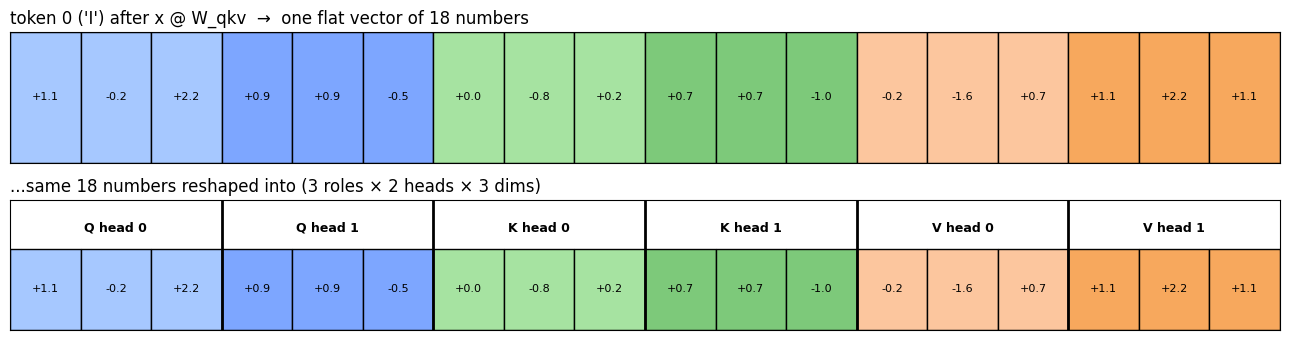

Same numbers, just grouped into Q/K/V × head — that's all 'split into heads' means.


In [62]:
# Pick token 0 ("I") to visualize
token_qkv_flat = x[0] @ W_qkv  # (18,)
token_qkv_3d = token_qkv_flat.view(3, n_head, d_head)  # (3, 2, 3)

# Show as colored rectangles
fig, axes = plt.subplots(2, 1, figsize=(13, 3.5))

# Top: the flat 18-vector
ax = axes[0]
flat = token_qkv_flat.detach().numpy()
for i in range(18):
    qkv_idx = i // (n_head * d_head)   # which of Q/K/V (0, 1, 2)
    head_idx = (i % (n_head * d_head)) // d_head  # which head
    color_map = {(0,0):'#a6c8ff', (0,1):'#7da6ff',  # Q: blue shades
                 (1,0):'#a6e3a1', (1,1):'#7dc97a',  # K: green
                 (2,0):'#fcc69e', (2,1):'#f7a85d'}  # V: orange
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color_map[(qkv_idx, head_idx)], edgecolor='black'))
    ax.text(i + 0.5, 0.5, f"{flat[i]:+.1f}", ha='center', va='center', fontsize=8)
ax.set_xlim(0, 18); ax.set_ylim(0, 1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("token 0 ('I') after x @ W_qkv  →  one flat vector of 18 numbers", loc='left')

# Bottom: same numbers, but reshaped and labeled by their (Q/K/V, head) role
ax = axes[1]
labels = ["Q head 0", "Q head 1", "K head 0", "K head 1", "V head 0", "V head 1"]
colors = ['#a6c8ff', '#7da6ff', '#a6e3a1', '#7dc97a', '#fcc69e', '#f7a85d']
chunks_3d = token_qkv_3d.detach().numpy()  # (3, 2, 3)
chunks = [chunks_3d[0, 0], chunks_3d[0, 1], chunks_3d[1, 0], chunks_3d[1, 1], chunks_3d[2, 0], chunks_3d[2, 1]]
x_offset = 0
for label, color, chunk in zip(labels, colors, chunks):
    for j, val in enumerate(chunk):
        ax.add_patch(plt.Rectangle((x_offset + j, 0), 1, 1, facecolor=color, edgecolor='black'))
        ax.text(x_offset + j + 0.5, 0.5, f"{val:+.1f}", ha='center', va='center', fontsize=8)
    ax.text(x_offset + d_head/2, 1.25, label, ha='center', va='center', fontsize=9, fontweight='bold')
    x_offset += d_head
    if x_offset < 18:
        ax.axvline(x_offset, color='black', lw=2)
ax.set_xlim(0, 18); ax.set_ylim(0, 1.6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("...same 18 numbers reshaped into (3 roles × 2 heads × 3 dims)", loc='left')

plt.tight_layout(); plt.show()
print("Same numbers, just grouped into Q/K/V × head — that's all 'split into heads' means.")

### Step C — Each head runs its own single-head attention (in parallel)

Now we have `n_head` separate `(Q, K, V)` triplets, one per head. Each one runs through *exactly* the same single-head attention algorithm we built in Section 1.3 — independently, in parallel.

```
for each head h in 0..n_head:
    scores_h  = q[h] @ k[h].T / sqrt(d_head)
    scores_h  = causal_mask(scores_h)
    weights_h = softmax(scores_h)
    out_h     = weights_h @ v[h]
```

PyTorch does this in one batched matmul (no Python loop), but conceptually it's just running 1.3 once per head.

In [63]:
scale = 1.0 / math.sqrt(d_head)
mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)

# Run attention for all heads at once (no Python loop — PyTorch handles the head dim)
scores = q @ k.transpose(-2, -1) * scale          # (n_head, T, T)
scores = scores.masked_fill(mask, float('-inf'))   # broadcast mask over heads
weights = F.softmax(scores, dim=-1)                # (n_head, T, T)
ctx = weights @ v                                  # (n_head, T, d_head)

print(f"per-head scores  shape: {tuple(scores.shape)}   = (n_head, T, T)")
print(f"per-head weights shape: {tuple(weights.shape)}  = (n_head, T, T)")
print(f"per-head context shape: {tuple(ctx.shape)}     = (n_head, T, d_head)")
print()
print("Head 0 attention weights (random init — no meaningful pattern yet):")
print(weights[0])
print()
print("Head 1 attention weights:")
print(weights[1])

per-head scores  shape: (2, 4, 4)   = (n_head, T, T)
per-head weights shape: (2, 4, 4)  = (n_head, T, T)
per-head context shape: (2, 4, 3)     = (n_head, T, d_head)

Head 0 attention weights (random init — no meaningful pattern yet):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.6285, 0.3715, 0.0000, 0.0000],
        [0.3375, 0.2497, 0.4128, 0.0000],
        [0.2850, 0.2602, 0.2753, 0.1796]])

Head 1 attention weights:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.6126, 0.3874, 0.0000, 0.0000],
        [0.4717, 0.3534, 0.1749, 0.0000],
        [0.2315, 0.2085, 0.1924, 0.3676]])


#### Visualizing per-head attention weights

Each head produces its own `(T, T)` attention matrix. With random initialization, the patterns aren't meaningful yet — but they're already **different from each other**, which is what enables specialization once we start training.

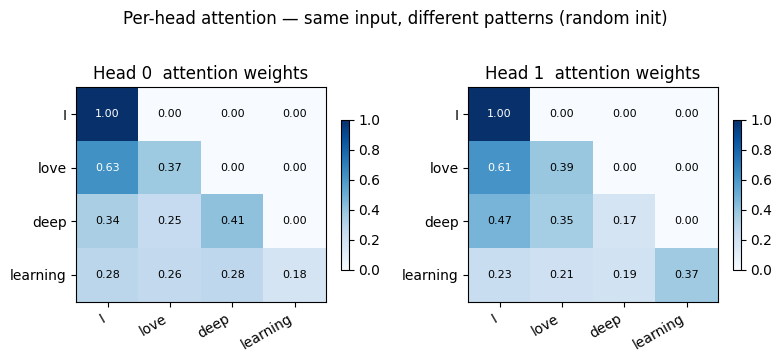

In [64]:
fig, axes = plt.subplots(1, n_head, figsize=(8, 3.5))
for h, ax in enumerate(axes):
    W = weights[h].detach().numpy()
    im = ax.imshow(W, cmap='Blues', vmin=0, vmax=W.max(), aspect='auto')
    ax.set_xticks(range(T)); ax.set_xticklabels(sentence, rotation=30, ha='right')
    ax.set_yticks(range(T)); ax.set_yticklabels(sentence)
    ax.set_title(f"Head {h}  attention weights")
    for i in range(T):
        for j in range(T):
            ax.text(j, i, f"{W[i,j]:.2f}", ha='center', va='center', fontsize=8,
                    color='white' if W[i,j] > W.max()*0.5 else 'black')
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle("Per-head attention — same input, different patterns (random init)", y=1.02)
plt.tight_layout(); plt.show()

### Step D — Concatenate the heads' outputs

Each head produced `ctx[h]` of shape `(T, d_head)`. To combine them, we **concatenate along the feature dimension**: head 0's 3 features, then head 1's 3 features, gives us `(T, 6) = (T, d_model)`.

In code this is `transpose(0, 1).contiguous().view(T, d_model)` — move the head dim back, then flatten the last two dims.

In [65]:
ctx_merged = ctx.transpose(0, 1).contiguous().view(T, d_model)

print(f"per-head context shape: {tuple(ctx.shape)}        = (n_head, T, d_head)")
print(f"after transpose:        {tuple(ctx.transpose(0,1).shape)}        = (T, n_head, d_head)")
print(f"after view (concat):    {tuple(ctx_merged.shape)}            = (T, n_head*d_head) = (T, d_model)")
print()
print("Each row of ctx_merged is now [ head_0's 3 features | head_1's 3 features ]:")
print(ctx_merged)

per-head context shape: (2, 4, 3)        = (n_head, T, d_head)
after transpose:        (4, 2, 3)        = (T, n_head, d_head)
after view (concat):    (4, 6)            = (T, n_head*d_head) = (T, d_model)

Each row of ctx_merged is now [ head_0's 3 features | head_1's 3 features ]:
tensor([[-0.1826, -1.5998,  0.7243,  1.0827,  2.1978,  1.1400],
        [-0.3243, -1.5505,  0.7615,  1.2319,  2.1285,  1.1694],
        [-0.6748, -1.4060,  0.8399,  1.0674,  2.0231,  1.0744],
        [-0.5399, -1.5130,  0.7723,  0.6116,  1.9902,  0.9558]])


#### Visualizing the concatenation

For each token, we glue the 3-dim outputs from head 0 and head 1 side-by-side to form a 6-dim vector. Different colors below mark which head each chunk came from.

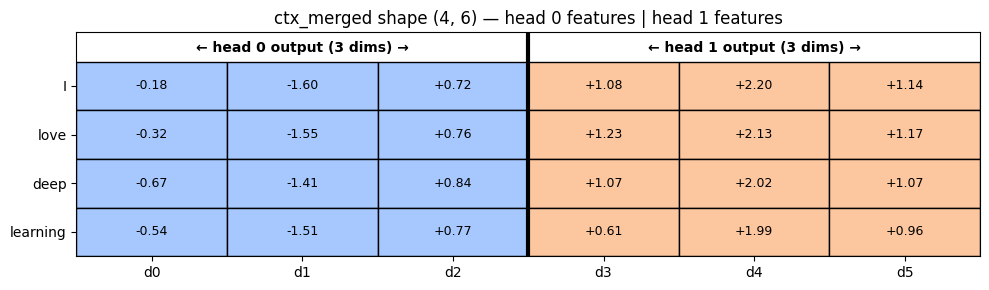

In [66]:
fig, ax = plt.subplots(figsize=(10, 3))
ctx_merged_np = ctx_merged.detach().numpy()
for i in range(T):
    for j in range(d_model):
        head_id = j // d_head
        color = ['#a6c8ff', '#fcc69e'][head_id]
        ax.add_patch(plt.Rectangle((j, T-1-i), 1, 1, facecolor=color, edgecolor='black'))
        ax.text(j + 0.5, T-1-i + 0.5, f"{ctx_merged_np[i, j]:+.2f}",
                ha='center', va='center', fontsize=9)
# Vertical line separating head 0 and head 1
ax.axvline(d_head, color='black', lw=3)
ax.text(d_head/2,  T + 0.2, "← head 0 output (3 dims) →", ha='center', fontsize=10, fontweight='bold')
ax.text(d_head + d_head/2, T + 0.2, "← head 1 output (3 dims) →", ha='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, d_model); ax.set_ylim(0, T + 0.6)
ax.set_xticks([d + 0.5 for d in range(d_model)]); ax.set_xticklabels([f"d{d}" for d in range(d_model)])
ax.set_yticks([T-1-i + 0.5 for i in range(T)]); ax.set_yticklabels(sentence)
ax.set_title(f"ctx_merged shape ({T}, {d_model}) — head 0 features | head 1 features")
plt.tight_layout(); plt.show()

### Step E — Final projection W_o

The concatenation just puts the heads side by side; it doesn't *combine* them. The final `W_o` projection (shape `d_model × d_model = 6 × 6`) lets the model learn how to **mix information across heads** — for example, "take 70% of head 0's first feature and 30% of head 1's second feature."

`out = ctx_merged @ W_o` is the final output of multi-head attention.

In [67]:
W_o = torch.randn(d_model, d_model) * 0.5
out_mha = ctx_merged @ W_o   # (T, d_model)

print(f"W_o shape: {tuple(W_o.shape)}    = (d_model, d_model)")
print(f"final output shape: {tuple(out_mha.shape)} = (T, d_model)  ← same as input!")
print()
print("Final multi-head attention output:")
print(out_mha)

W_o shape: (6, 6)    = (d_model, d_model)
final output shape: (4, 6) = (T, d_model)  ← same as input!

Final multi-head attention output:
tensor([[ 0.6828, -0.0420, -1.1831,  3.3161, -2.9892, -0.8552],
        [ 0.6206, -0.2443, -1.2370,  3.3066, -3.0039, -0.7060],
        [ 0.4745, -0.3842, -1.0365,  2.8444, -2.7523, -0.2990],
        [ 0.5711,  0.0080, -0.8563,  2.5508, -2.5024, -0.2895]])


### Multi-head pipeline — full picture

```
                          x  (T=4, d_model=6)
                                   |
                          x @ W_qkv  (one big projection)
                                   |
                                   ▼
                       qkv: (T, 3*d_model) = (4, 18)
                                   |
                            view + split
                                   |
                         ┌─────────┴─────────┐
                         ▼                   ▼
                     head 0              head 1
                  (T, d_head=3)       (T, d_head=3)
                  q0,k0,v0            q1,k1,v1
                       |                    |
                   single-head          single-head
                   attention            attention
                  (Section 1.3)        (Section 1.3)
                       |                    |
                     out0                 out1
                  (T, d_head)          (T, d_head)
                         └─────────┬─────────┘
                                   ▼
                              concatenate
                          (T, n_head*d_head)
                                   = (T, d_model)
                                   |
                                @ W_o
                                   |
                                   ▼
                              MHA output
                              (T, d_model)
```

### Why the shape constraint exists

The reason `d_model = n_head × d_head` is now obvious from the diagram: when we concatenate `n_head` outputs of size `d_head`, we get `n_head × d_head` total features — and that has to equal `d_model` so the block produces what the *next* block expects as input.

It's the same reason a Lego block's bumps line up with the next block's holes — without it, the stack falls apart.

### Compare with `multi_head.py`

Now `multi_head.py` should be very readable. It does exactly what we did above, with `trace_shapes=True` printing the same shapes you saw here.

In [68]:
from multi_head import MultiHeadSelfAttention

torch.manual_seed(0)
mha = MultiHeadSelfAttention(d_model=d_model, n_head=n_head, trace_shapes=True)

# Add batch dimension
out_module, w_module = mha(x.unsqueeze(0))
print()
print(f"final out shape:      {tuple(out_module.shape)} = (B, T, d_model)")
print(f"per-head weights:     {tuple(w_module.shape)} = (B, n_head, T, T)")

qkv view: torch.Size([1, 4, 3, 2, 3])
q: torch.Size([1, 2, 4, 3]) k: torch.Size([1, 2, 4, 3]) v: torch.Size([1, 2, 4, 3])
weights: torch.Size([1, 2, 4, 4]) ctx: torch.Size([1, 2, 4, 3])
out: torch.Size([1, 4, 6])

final out shape:      (1, 4, 6) = (B, T, d_model)
per-head weights:     (1, 2, 4, 4) = (B, n_head, T, T)


### Key takeaways

1. **Single head**: one set of `(Q, K, V)` matrices, one attention pattern.
2. **Multi-head**: `n_head` independent attentions in parallel, each in a smaller `d_head`-dim subspace.
3. **Same compute** as a single big head, but the model can learn `n_head` different "lenses" on the same input.
4. **Same input data** flows to every head — but **different random weights** make each head transform it differently. Training then *rewards* heads that learn complementary patterns (specialization is emergent, not designed).
5. **The constraint `d_model = n_head × d_head`** exists so that concatenating the heads produces a `d_model`-wide vector, which is what the next block expects.

---
## 1.5a Feed-Forward Network (FFN)

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]

    pe["1.1 Positional Encoding<br>add position info"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward<br>Linear -> GELU -> Linear"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style pe fill:#e8e8e8,stroke:#bbb,color:#777
    style ln1 fill:#e8e8e8,stroke:#bbb,color:#777
    style mha fill:#e8e8e8,stroke:#bbb,color:#777
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style ln2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#fff3c4,stroke:#b38600,stroke-width:3px,color:#000
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

### The question

After MHA, each token has *gathered* information from the other tokens. Now each token needs to *process* that information. That's what the FFN does — it applies the same small neural network to each token position **independently** (no cross-token mixing).

Think of it as: "attention = communication, FFN = computation."

### The structure

```
Input (B, T, d_model)
   |
   v
Linear(d_model, 4*d_model)   <- expand to 4x wider
   |
   v
GELU                         <- non-linearity
   |
   v
Linear(4*d_model, d_model)   <- project back down
   |
   v
Dropout
   |
   v
Output (B, T, d_model)
```

**Why expand 4x?** The expansion gives more capacity to learn non-linear transformations. It's the largest source of parameters in a Transformer — typically ~2/3 of all parameters live in FFN layers.

**Why GELU, not ReLU?** GELU is smooth — its derivative is continuous everywhere, which helps gradient flow. At large positive x it behaves like ReLU (passes through), at large negative x it's zero, but around zero it's smoothly curved instead of a sharp kink.

### Visualization: GELU vs ReLU

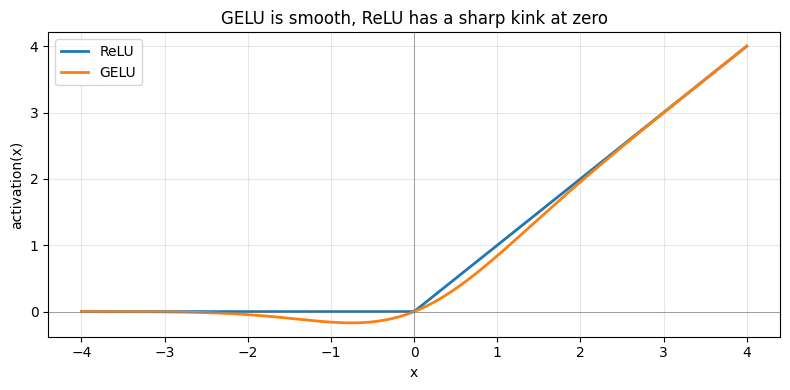

In [69]:
x = torch.linspace(-4, 4, 200)
relu = F.relu(x)
gelu = F.gelu(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x.numpy(), relu.numpy(), label='ReLU', linewidth=2)
ax.plot(x.numpy(), gelu.numpy(), label='GELU', linewidth=2)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.legend()
ax.set_xlabel('x'); ax.set_ylabel('activation(x)')
ax.set_title('GELU is smooth, ReLU has a sharp kink at zero')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Run it

In [70]:
from ffn import FeedForward

ffn = FeedForward(d_model=64, mult=4)
print("parameters:", sum(p.numel() for p in ffn.parameters()))
print(f"  breakdown: 64*256 (expand) + 256 (bias) + 256*64 (project) + 64 (bias) = {64*256 + 256 + 256*64 + 64}")

x = torch.randn(2, 10, 64)
y = ffn(x)
print("\ninput: ", x.shape)
print("output:", y.shape, "  # same as input — FFN preserves shape")

parameters: 33088
  breakdown: 64*256 (expand) + 256 (bias) + 256*64 (project) + 64 (bias) = 33088

input:  torch.Size([2, 10, 64])
output: torch.Size([2, 10, 64])   # same as input — FFN preserves shape


### Shape trace

| Stage | Shape | Operation |
|-------|-------|-----------|
| Input `x` | `(B, T, d_model)` | token representations after MHA |
| After first `Linear` | `(B, T, 4*d_model)` | expand |
| After `GELU` | `(B, T, 4*d_model)` | non-linearity (same shape) |
| After second `Linear` | `(B, T, d_model)` | project back |

**The FFN is applied to each token independently** — no communication between positions. That's attention's job.

---
## 1.5b LayerNorm + Residual Connections

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]

    pe["1.1 Positional Encoding<br>add position info"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward<br>Linear -> GELU -> Linear"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style pe fill:#e8e8e8,stroke:#bbb,color:#777
    style ln1 fill:#e8daef,stroke:#6c3483,stroke-width:3px,color:#000
    style mha fill:#e8e8e8,stroke:#bbb,color:#777
    style add1 fill:#fdd,stroke:#c33,stroke-width:3px,color:#000
    style ln2 fill:#e8daef,stroke:#6c3483,stroke-width:3px,color:#000
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#fdd,stroke:#c33,stroke-width:3px,color:#000
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

These are the glue that makes deep Transformers trainable. Every sublayer (MHA, FFN) is wrapped like this:

```python
x = x + sublayer(LayerNorm(x))
```

Two things happening:
1. **LayerNorm** — normalize the activations so they don't drift
2. **Residual connection** (the `x +`) — provide a "highway" for gradients

### LayerNorm: normalize per token, across features

For each token (one row of the `(B, T, d_model)` tensor), compute:

$$
\text{LN}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

where `μ, σ²` are the mean and variance **across the `d_model` features of that token** (not across batch, unlike BatchNorm). `γ, β` are learnable scale + shift.

**Why LayerNorm and not BatchNorm?**
- LayerNorm doesn't depend on batch statistics — works the same at train and test time
- Works for variable-length sequences (batch sizes of 1 are fine)
- Plays nicely with attention, which expects each token to be a self-contained unit

### Residual connection: the gradient highway

`x = x + sublayer(...)` means:
- The **forward** pass has two paths: through the sublayer, and straight through the `+`
- The **backward** pass also has two paths — gradient can skip the sublayer entirely via the `+`
- Even if the sublayer "kills" the gradient (common in deep nets), the skip path keeps it flowing

Without residuals, training a 12-layer (let alone 96-layer) Transformer is nearly impossible.

### Pre-Norm vs Post-Norm

The original Transformer paper (2017) used **Post-Norm**: `x = LN(x + sublayer(x))`.
Modern GPTs use **Pre-Norm**: `x = x + sublayer(LN(x))` — more stable to train, that's what we use here.

Notice in the diagram: LN comes *before* MHA and FFN, not after.

### Visualization: LayerNorm in action on a tiny tensor

Pick 4 tokens, each with 8 features. Before LN: arbitrary values with some mean and spread. After LN: each row has mean≈0 and std≈1.

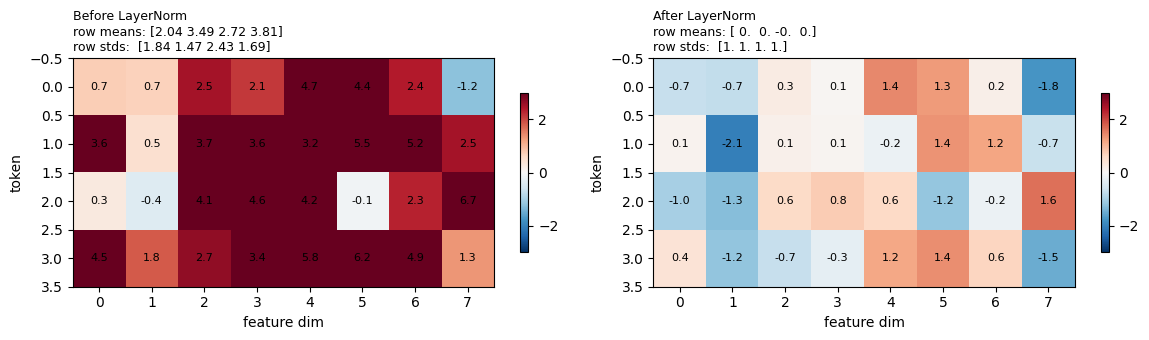

In [71]:
torch.manual_seed(0)
x = torch.randn(4, 8) * 2 + 3  # (4 tokens, 8 features)
ln = nn.LayerNorm(8, elementwise_affine=False)  # no gamma/beta for visualization clarity
y = ln(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, mat, title in zip(axes, [x.numpy(), y.numpy()], ["Before LayerNorm", "After LayerNorm"]):
    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
    ax.set_title(title + f"\nrow means: {mat.mean(1).round(2)}\nrow stds:  {mat.std(1).round(2)}",
                 fontsize=9, loc='left')
    ax.set_xlabel("feature dim"); ax.set_ylabel("token")
    for i in range(4):
        for j in range(8):
            ax.text(j, i, f"{mat[i,j]:.1f}", ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

### Visualization: why residual connections are a "highway"

Without residuals, the gradient flowing from output to input must survive every sublayer. With residuals, it has a direct path.

```
Without residual:  gradient must pass through each sublayer untouched
    loss <-- sublayer_N <-- ... <-- sublayer_1 <-- input

With residual:    gradient has a skip path around each sublayer
    loss <-- (+ skip) <-- ... <-- (+ skip) <-- input
```

Even if each sublayer multiplies gradients by `0.9`, after 24 layers the signal is `0.9^24 ≈ 0.08` — vanishing. With residual skips, the unchanged path is always available.

---
## 1.6 The Full Transformer Block

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]

    pe["1.1 Positional Encoding<br>add position info"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward<br>Linear -> GELU -> Linear"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8f4fd,stroke:#2874a6,stroke-width:3px,color:#000
    style pe fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ln1 fill:#e8daef,stroke:#6c3483,stroke-width:3px,color:#000
    style mha fill:#fdebd0,stroke:#b35900,stroke-width:3px,color:#000
    style add1 fill:#fdd,stroke:#c33,stroke-width:3px,color:#000
    style ln2 fill:#e8daef,stroke:#6c3483,stroke-width:3px,color:#000
    style ffn fill:#fff3c4,stroke:#b38600,stroke-width:3px,color:#000
    style add2 fill:#fdd,stroke:#c33,stroke-width:3px,color:#000
    style output fill:#e8f4fd,stroke:#2874a6,stroke-width:3px,color:#000
```

### Assembly

From `block.py`:

```python
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_head, dropout=0.0):
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_head, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ffn  = FeedForward(d_model, mult=4, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))[0]   # communicate
        x = x + self.ffn (self.ln2(x))      # compute
        return x
```

Two lines for the whole block, after all that work! The pattern is `x = x + sublayer(LN(x))` applied twice — once for attention, once for FFN.

### Full forward pass with shape trace

In [72]:
from block import TransformerBlock

torch.manual_seed(0)
block = TransformerBlock(d_model=64, n_head=4)
print(f"Total parameters: {sum(p.numel() for p in block.parameters()):,}")
print()

# Count parameters per submodule
for name, mod in block.named_children():
    n_params = sum(p.numel() for p in mod.parameters())
    print(f"  {name:10s} : {n_params:>7,} params")

Total parameters: 49,728

  ln1        :     128 params
  attn       :  16,384 params
  ln2        :     128 params
  ffn        :  33,088 params


In [73]:
# Trace one forward pass with shape prints at every intermediate step
x = torch.randn(2, 10, 64)  # (B=2, T=10, d_model=64)
print("input x:            ", x.shape)

h = block.ln1(x)
print("after ln1:          ", h.shape)

attn_out, attn_w = block.attn(h)
print("after attention:    ", attn_out.shape, "  (attention weights:", attn_w.shape, ")")

x1 = x + attn_out
print("after residual 1:   ", x1.shape)

h2 = block.ln2(x1)
print("after ln2:          ", h2.shape)

ff_out = block.ffn(h2)
print("after FFN:          ", ff_out.shape)

x2 = x1 + ff_out
print("final output:       ", x2.shape)

input x:             torch.Size([2, 10, 64])
after ln1:           torch.Size([2, 10, 64])
qkv view: torch.Size([2, 10, 3, 4, 16])
q: torch.Size([2, 4, 10, 16]) k: torch.Size([2, 4, 10, 16]) v: torch.Size([2, 4, 10, 16])
weights: torch.Size([2, 4, 10, 10]) ctx: torch.Size([2, 4, 10, 16])
out: torch.Size([2, 10, 64])
after attention:     torch.Size([2, 10, 64])   (attention weights: torch.Size([2, 4, 10, 10]) )
after residual 1:    torch.Size([2, 10, 64])
after ln2:           torch.Size([2, 10, 64])
after FFN:           torch.Size([2, 10, 64])
final output:        torch.Size([2, 10, 64])


### Stacking blocks into a model

A full GPT model is: token embedding + position encoding + **N Transformer blocks stacked** + final LayerNorm + linear head to vocab size. That's Part 2. But you've now built the fundamental unit that gets repeated.

```
Tokens -> Embed -> + PE -> [Block] x N -> LN -> Linear -> logits -> softmax -> next-token probs
```

---
## Recap

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]

    pe["1.1 Positional Encoding<br>add position info"]
    ln1["1.5 LayerNorm 1"]
    mha["1.3/1.4 Multi-Head Attention<br>(Q, K, V + causal mask)"]
    add1["+ residual"]
    ln2["1.5 LayerNorm 2"]
    ffn["1.5 Feed-Forward<br>Linear -> GELU -> Linear"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> pe --> ln1 --> mha --> add1
    pe --> add1
    add1 --> ln2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8f4fd,stroke:#2874a6,stroke-width:3px,color:#000
    style pe fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ln1 fill:#e8daef,stroke:#6c3483,stroke-width:3px,color:#000
    style mha fill:#fdebd0,stroke:#b35900,stroke-width:3px,color:#000
    style add1 fill:#fdd,stroke:#c33,stroke-width:3px,color:#000
    style ln2 fill:#e8daef,stroke:#6c3483,stroke-width:3px,color:#000
    style ffn fill:#fff3c4,stroke:#b38600,stroke-width:3px,color:#000
    style add2 fill:#fdd,stroke:#c33,stroke-width:3px,color:#000
    style output fill:#e8f4fd,stroke:#2874a6,stroke-width:3px,color:#000
```

You've built every piece of the Transformer block:

| Section | Piece | Purpose |
|---------|-------|---------|
| **1.1** | Positional encoding | tell the model where each token is |
| **1.2** | Self-attention math | content-based information gathering |
| **1.3** | Single head in PyTorch | same math, now trainable |
| **1.4** | Multi-head attention | multiple attention patterns in parallel |
| **1.5a** | Feed-forward | per-token computation |
| **1.5b** | LayerNorm + residuals | make deep networks trainable |
| **1.6** | Full block | assemble into one unit |

### What's next — Part 2

The block you just built is the core repeated unit. To turn it into a working language model you need:
- **Token embedding** — map vocabulary IDs to dense vectors
- **Stack of blocks** — typically 6 / 12 / 24 / 96 layers
- **LM head** — project the final `d_model` back to vocab size
- **Loss function** — cross-entropy on next-token prediction
- **Training loop** — data batching, optimizer, eval
- **Sampling** — temperature, top-k, top-p

All of that is Part 2. But the hardest conceptual lifting is done.